# Attribute Mining Window Sweep — EDA

Cross-configuration EDA of the attribute-mining pipeline, sourced from
`artifacts/mining/*_symbolic_cscas_*gran*_win*/attribute_mining/` -- the sweep grid
written by `sweep_attribute_schema.py`. Mining has two sequential stages: **Step 1**
(`thesis.mining.attribute_contrast_mining`) filters categorical contrast-set itemsets
by `min_growth_rate`/`min_attack_coverage`/`min_benign_coverage`; **Step 2**
(`thesis.mining.decision_tree_rule_mining.fit_and_extract_rules`) builds decision
tree(s) over the numeric attributes. Step 2 now fits **two independent trees** --
`max_depth` for the benign-leaning tree, `max_depth_attack` for the attack-leaning
tree -- replacing an earlier single-shared-depth design that turned out to be
structurally unable to satisfy both an attack-precision floor and a benign-recall
floor at once (see section 5.3's history for why).

This is a full re-mine, not an extension of prior data: fitting two trees is a
different Step-2 algorithm, so none of the single-tree grid this notebook analyzed
before exists anymore -- 336 runs, none of them a rectangle. Every axis was swept
*alone*, holding every other axis at an anchor value in the *other* stage (Step 1's
sweeps anchored at a Step-2 default, Step 2's sweeps anchored at a Step-1 default),
plus one small `growth_rate x max_depth_attack` cross-check -- see
`sweep_attribute_schema.py`'s module docstring for the full rationale. That shape
means a lot of code below filters `grid_df` by an *explicit* combination of every
axis's anchor, not just "the one axis I'm looking at" -- several axes share the same
`growth_rate`/`max_depth` value across different sweeps, so leaving one axis
unconstrained silently mixes rows from different sweeps together.

**What this notebook is for.** Earlier phases of this analysis were diagnostic:
characterize each parameter's effect, to argue for freezing some and varying others
(see `summaries/ATTRIBUTE_MINING_PARAMETER_ANALYSIS.md`), and establish a quality bar
tied to the schema's real job (helping a classifier/anomaly detector reduce false
positives). That last piece hit a wall under single-tree Step 2 -- zero configs out of
36 cleared both a precision and a recall floor simultaneously, because one shared
depth structurally couldn't serve both. The two-tree redesign exists to remove that
wall. This notebook's job now includes a fourth, concluding piece the single-tree
version couldn't reach: confirm the redesign actually decouples the two metrics, and
use it to name a specific, defensible mining configuration to carry into the next
round of experiments -- not just characterize parameters in the abstract, but end with
an answer.


In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

FIGURES_DIR = Path("../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# Fixed categorical colours, assigned once and reused throughout -- never
# re-derived per plot, so the same growth_rate/max_depth always gets the same
# colour across every figure in this notebook.
GRAN_PALETTE = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377"]
ATTACK_COLOR = "#CC3311"   # warm -> attack-leaning / attack class
BENIGN_COLOR = "#4477AA"   # cool -> benign-leaning / benign class
NEUTRAL_COLOR = "#BBBBBB"


def gran_color_map(grans: list[float]) -> dict[float, str]:
    return {g: GRAN_PALETTE[i % len(GRAN_PALETTE)] for i, g in enumerate(sorted(grans))}


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a 300dpi copy for the thesis alongside the inline notebook display."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  saved {path}")


def strip_axes(ax) -> None:
    ax.grid(axis="y", alpha=0.25)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def base_feature(token: str) -> str:
    """Strip NOT_/threshold suffix to get the underlying attribute name, e.g.
    'NOT_multi_target' -> 'multi_target',
    'signature_matches_per_day_le_143.7' -> 'signature_matches_per_day'.
    """
    t = token.strip()
    if t.startswith("NOT_"):
        t = t[4:]
    m = re.match(r"^(.*)_(le|gt)_[-0-9.eE]+$", t)
    return m.group(1) if m else t


## 1. Grid loading & setup

In [3]:
import json

import yaml

MINING_ROOT = Path("../../../artifacts/mining")
SCENARIO = "cscas"

# Matches run names produced by sweep_attribute_schema.py, which embeds the full
# config (gr/md/mda/cw/msl/ac/bc) between the scenario and "gran{g}_win{w}". `.*`
# swallows those config tokens; gran/win_idx still only ever appear once, right
# before the end.
RUN_NAME_RE = re.compile(rf"^\d{{8}}_\d{{6}}_symbolic_{SCENARIO}_.*gran([\d.]+)_win(\d+)$")

_RUN_DIR_CSVS = ("mined_attribute_features.csv", "contrast_stats_all.csv", "contrast_survivors.csv")


def _run_dir_is_valid(mining_dir: Path) -> bool:
    """True if every CSV this notebook reads out of a run_dir parses cleanly --
    a thread-pool run racing two writers on one path can interleave their byte
    streams into a file that belongs to neither config (wrong field count, or an
    itemset string truncated mid-token). Catching that here turns it into a
    printed skip instead of a baffling downstream traceback."""
    for fname in _RUN_DIR_CSVS:
        path = mining_dir / fname
        if not path.exists():
            return False
        try:
            df = pd.read_csv(path)
        except Exception:
            return False
        if "itemset" in df.columns:
            try:
                df["itemset"].apply(ast.literal_eval)
            except Exception:
                return False
    return True


rows = []
skip_reasons = []
for run_dir in sorted(MINING_ROOT.iterdir()):
    m = RUN_NAME_RE.match(run_dir.name)
    if m is None:
        continue
    mining_dir = run_dir / "attribute_mining"
    cfg_path, meta_path = mining_dir / "config.yaml", mining_dir / "metadata.json"
    if not (cfg_path.exists() and meta_path.exists()):
        continue
    if not _run_dir_is_valid(mining_dir):
        skip_reasons.append(run_dir.name)
        continue
    cfg = yaml.safe_load(cfg_path.read_text())
    meta = json.loads(meta_path.read_text())
    rows.append({
        "run_dir": run_dir.name,
        "growth_rate": cfg["contrast"]["min_growth_rate"],
        "min_growth_rate_attack": cfg["contrast"].get("min_growth_rate_attack"),
        "max_depth": cfg["tree"]["max_depth"],
        "max_depth_attack": cfg["tree"].get("max_depth_attack"),
        "min_attack_coverage": cfg["contrast"]["min_attack_coverage"],
        "min_benign_coverage": cfg["contrast"]["min_benign_coverage"],
        "class_weight": cfg["tree"]["class_weight"],
        "min_samples_leaf": cfg["tree"]["min_samples_leaf"],
        "gran": float(m.group(1)),
        "win_idx": int(m.group(2)),
        "n_alert_groups": meta["n_alert_groups"],
        "mining_dir": mining_dir,
    })

grid_df = pd.DataFrame(rows)
grid_df = grid_df.drop_duplicates(
    subset=["growth_rate", "min_growth_rate_attack", "max_depth", "max_depth_attack", "class_weight",
            "min_samples_leaf", "min_attack_coverage", "min_benign_coverage", "gran", "win_idx"],
    keep="last",
)
grid_df = grid_df.sort_values(
    ["growth_rate", "min_growth_rate_attack", "max_depth", "max_depth_attack", "gran", "win_idx"]
).reset_index(drop=True)

# Anchors sweep_attribute_schema.py built this grid around -- every axis below was
# swept ALONE against these, never crossed with every other axis, so there's no
# full rectangle to assert completeness over the way the old single-tree grid had.
# max_depth_attack=None only ever happens for pre-two-tree runs, none of which
# exist anymore (this is a full re-mine) -- kept as a defensive default, not
# something expected to actually appear in GROWTH_RATES/etc below.
STEP1_ANCHOR_GROWTH_RATE = 3.0
STEP1_ANCHOR_ATTACK_COVERAGE = 0.05
STEP1_ANCHOR_BENIGN_COVERAGE = 0.05
STEP2_ANCHOR_MAX_DEPTH = 1
STEP2_ANCHOR_MAX_DEPTH_ATTACK = 3
STEP2_ANCHOR_CLASS_WEIGHT = "balanced"
STEP2_ANCHOR_MIN_SAMPLES_LEAF = 20

GROWTH_RATES = sorted(grid_df["growth_rate"].unique())
GROWTH_RATES_ATTACK = sorted(grid_df["min_growth_rate_attack"].dropna().unique())
MAX_DEPTHS = sorted(grid_df["max_depth"].unique())
MAX_DEPTHS_ATTACK = sorted(grid_df["max_depth_attack"].dropna().unique())
GRANULARITIES = sorted(grid_df["gran"].unique())

# Reusable masks: which subset of grid_df answers "what does axis X alone do,
# holding every other axis -- both Step-2 depths included -- at its anchor".
# Defined once here so every section below filters consistently; several axes
# below share the same growth_rate/max_depth value across different sweeps
# (e.g. growth_rate=3.0 appears in the growth_rate sweep, the max_depth sweep,
# the max_depth_attack sweep, and the class_weight sweep alike), so leaving
# either Step-2 depth unconstrained would silently blend rows from different
# sweeps into one "average". min_growth_rate_attack.isna() anchors every sweep
# below at "no split" -- without it, the 48 min_growth_rate_attack rows (which
# otherwise match every other anchor field) would silently contaminate these
# masks now that they're distinguishable from the growth_rate=3.0 baseline.
_STEP2_ANCHOR = (
    (grid_df["class_weight"] == STEP2_ANCHOR_CLASS_WEIGHT)
    & (grid_df["min_samples_leaf"] == STEP2_ANCHOR_MIN_SAMPLES_LEAF)
    & (grid_df["min_attack_coverage"] == STEP1_ANCHOR_ATTACK_COVERAGE)
    & (grid_df["min_benign_coverage"] == STEP1_ANCHOR_BENIGN_COVERAGE)
)
GROWTH_RATE_SWEEP_MASK = (
    _STEP2_ANCHOR
    & (grid_df["max_depth"] == STEP2_ANCHOR_MAX_DEPTH)
    & (grid_df["max_depth_attack"] == STEP2_ANCHOR_MAX_DEPTH_ATTACK)
    & (grid_df["min_growth_rate_attack"].isna())
)
MAX_DEPTH_SWEEP_MASK = (
    _STEP2_ANCHOR
    & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)
    & (grid_df["max_depth_attack"] == STEP2_ANCHOR_MAX_DEPTH_ATTACK)
    & (grid_df["min_growth_rate_attack"].isna())
)
MAX_DEPTH_ATTACK_SWEEP_MASK = (
    _STEP2_ANCHOR
    & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)
    & (grid_df["max_depth"] == STEP2_ANCHOR_MAX_DEPTH)
    & (grid_df["min_growth_rate_attack"].isna())
)
COVERAGE_SWEEP_MASK = (
    (grid_df["class_weight"] == STEP2_ANCHOR_CLASS_WEIGHT)
    & (grid_df["min_samples_leaf"] == STEP2_ANCHOR_MIN_SAMPLES_LEAF)
    & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)
    & (grid_df["max_depth"] == STEP2_ANCHOR_MAX_DEPTH)
    & (grid_df["max_depth_attack"] == STEP2_ANCHOR_MAX_DEPTH_ATTACK)
    & (grid_df["min_growth_rate_attack"].isna())
)
CLASS_WEIGHT_SWEEP_MASK = (
    (grid_df["min_samples_leaf"] == STEP2_ANCHOR_MIN_SAMPLES_LEAF)
    & (grid_df["min_attack_coverage"] == STEP1_ANCHOR_ATTACK_COVERAGE)
    & (grid_df["min_benign_coverage"] == STEP1_ANCHOR_BENIGN_COVERAGE)
    & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)
    & (grid_df["max_depth"] == STEP2_ANCHOR_MAX_DEPTH)
    & (grid_df["max_depth_attack"] == STEP2_ANCHOR_MAX_DEPTH_ATTACK)
    & (grid_df["min_growth_rate_attack"].isna())
)
CROSS_CHECK_MASK = (
    _STEP2_ANCHOR
    & (grid_df["max_depth"] == STEP2_ANCHOR_MAX_DEPTH)
    & (grid_df["growth_rate"].isin([2.0, 10.0]))
    & (grid_df["max_depth_attack"].isin([1, 5]))
    & (grid_df["min_growth_rate_attack"].isna())
)
# min_growth_rate_attack swept alone at the Step-1/Step-2 anchor (growth_rate=3.0,
# max_depth=1, max_depth_attack=3) -- deliberately NOT constrained on its own
# column, since that's the axis varying. Naturally includes both the 3 explicit
# values (2.0, 5.0, 10.0) and the None-anchor row (growth_rate=3.0 itself, which
# doubles as this axis's "no split" reference point -- see STEP1_GROWTH_RATES_ATTACK's
# own comment in sweep_attribute_schema.py for why 3.0 was never separately mined).
GROWTH_RATE_ATTACK_SWEEP_MASK = (
    _STEP2_ANCHOR
    & (grid_df["max_depth"] == STEP2_ANCHOR_MAX_DEPTH)
    & (grid_df["max_depth_attack"] == STEP2_ANCHOR_MAX_DEPTH_ATTACK)
    & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)
)
ANCHOR_MASK = GROWTH_RATE_SWEEP_MASK & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)


def _check_axis_completeness(label: str, mask: pd.Series, group_col: str) -> None:
    sub = grid_df[mask]
    ok = True
    for gran in sorted(sub["gran"].unique()):
        win_sets = sub[sub.gran == gran].groupby(group_col)["win_idx"].apply(lambda s: frozenset(s))
        if win_sets.nunique() > 1:
            print(f"  WARNING: {label} @ gran={gran:g} has inconsistent window coverage: {win_sets.to_dict()}")
            ok = False
    if ok:
        print(f"  OK: {label} -- consistent window coverage across every {group_col} value, every granularity")


if skip_reasons:
    print(f"Skipped {len(skip_reasons)} run_dir(s) with corrupted CSVs: {skip_reasons}")
print(f"Found {len(grid_df)} mining runs (deduped) under {MINING_ROOT.resolve()}")
print(f"growth_rate={[float(g) for g in GROWTH_RATES]}  growth_rate_attack={[float(g) for g in GROWTH_RATES_ATTACK]}  "
      f"max_depth={[int(d) for d in MAX_DEPTHS]}  max_depth_attack={[int(d) for d in MAX_DEPTHS_ATTACK]}  "
      f"granularity={[float(g) for g in GRANULARITIES]}")
for gran in GRANULARITIES:
    n_win = grid_df[grid_df.gran == gran]["win_idx"].nunique()
    print(f"  gran={gran:g}: {n_win} window(s)")
print()
_check_axis_completeness("growth_rate sweep", GROWTH_RATE_SWEEP_MASK, "growth_rate")
_check_axis_completeness("max_depth (benign) sweep", MAX_DEPTH_SWEEP_MASK, "max_depth")
_check_axis_completeness("max_depth_attack sweep", MAX_DEPTH_ATTACK_SWEEP_MASK, "max_depth_attack")
_check_axis_completeness("min_growth_rate_attack sweep", GROWTH_RATE_ATTACK_SWEEP_MASK, "min_growth_rate_attack")


Found 384 mining runs (deduped) under /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/mining
growth_rate=[2.0, 3.0, 5.0, 10.0]  growth_rate_attack=[2.0, 5.0, 10.0]  max_depth=[1, 2, 3]  max_depth_attack=[1, 2, 3, 4, 5]  granularity=[0.1, 0.25, 0.5]
  gran=0.1: 10 window(s)
  gran=0.25: 4 window(s)
  gran=0.5: 2 window(s)

  OK: growth_rate sweep -- consistent window coverage across every growth_rate value, every granularity
  OK: max_depth (benign) sweep -- consistent window coverage across every max_depth value, every granularity
  OK: max_depth_attack sweep -- consistent window coverage across every max_depth_attack value, every granularity
  OK: min_growth_rate_attack sweep -- consistent window coverage across every min_growth_rate_attack value, every granularity


In [4]:
def grid_point_stats(row: pd.Series) -> dict:
    feats = pd.read_csv(row["mining_dir"] / "mined_attribute_features.csv")
    feats["itemset"] = feats["itemset"].apply(ast.literal_eval)
    contrast = feats[feats["mining_type"] == "contrast_categorical"]
    contrast_attack = contrast[contrast["source_label"] == "attack"]
    contrast_benign = contrast[contrast["source_label"] == "benign"]
    tree = feats[feats["mining_type"] == "decision_tree_rule"]
    tree_attack = tree[tree["source_label"] == "attack"]
    tree_benign = tree[tree["source_label"] == "benign"]

    n_step1_candidates = len(pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv"))

    base_counts: dict[str, int] = {}
    for itemset in tree["itemset"]:
        for tok in itemset:
            feat = base_feature(tok)
            base_counts[feat] = base_counts.get(feat, 0) + 1
    top2_feature_share = (
        sum(sorted(base_counts.values(), reverse=True)[:2]) / len(tree) if base_counts else np.nan
    )

    return {
        "n_step1_candidates": n_step1_candidates,
        "n_contrast": len(contrast),
        "n_contrast_attack": len(contrast_attack),
        "n_contrast_benign": len(contrast_benign),
        "n_tree_leaves": len(tree),
        # Two independent trees now -- leaf counts split by which tree produced
        # them (max_depth governs the benign tree, max_depth_attack the attack
        # one), not just by source_label as a post-hoc split of one shared tree.
        "n_tree_leaves_attack": len(tree_attack),
        "n_tree_leaves_benign": len(tree_benign),
        "n_features": len(feats),
        "n_features_attack": int((feats["source_label"] == "attack").sum()),
        "n_features_benign": int((feats["source_label"] == "benign").sum()),
        # confidence_attack/confidence_benign (mining_job's own column names) are
        # per-class RECALL -- n_class_in_leaf / n_class_total_in_TREE, i.e. what
        # share of all attacks (or all benign) this one leaf alone captures, not
        # purity. precision_attack/_benign below are the actual purity metrics
        # (n_class_in_leaf / leaf_size), computed here from each leaf's own
        # n_attack/n_benign counts since mined_attribute_features.csv's own
        # precision_attack column is only populated for Step-1 rows.
        "mean_tree_recall_attack": tree_attack["confidence_attack"].mean() if len(tree_attack) else np.nan,
        "mean_tree_recall_benign": tree_benign["confidence_benign"].mean() if len(tree_benign) else np.nan,
        "mean_tree_precision_attack": (
            (tree_attack["n_attack"] / (tree_attack["n_attack"] + tree_attack["n_benign"])).mean()
            if len(tree_attack) else np.nan
        ),
        "mean_tree_precision_benign": (
            (tree_benign["n_benign"] / (tree_benign["n_attack"] + tree_benign["n_benign"])).mean()
            if len(tree_benign) else np.nan
        ),
        "mean_rule_length": tree["itemset"].apply(len).mean() if len(tree) else np.nan,
        "n_distinct_base_features": len(base_counts),
        "top2_feature_share": top2_feature_share,
        # Identity sets for the temporal-stability section below. Step 1's
        # vocabulary is a small fixed alphabet of categorical values; Step 2's
        # splits are continuous thresholds that shift with the data even when
        # the underlying attribute doesn't, so base_feature() strips those.
        "_contrast_itemset_set": frozenset(t[0] for t in contrast["itemset"]),
        "_contrast_itemset_set_attack": frozenset(t[0] for t in contrast_attack["itemset"]),
        "_contrast_itemset_set_benign": frozenset(t[0] for t in contrast_benign["itemset"]),
        "_tree_base_set_attack": frozenset(base_feature(tok) for itemset in tree_attack["itemset"] for tok in itemset),
        "_tree_base_set_benign": frozenset(base_feature(tok) for itemset in tree_benign["itemset"] for tok in itemset),
    }


grid_df = pd.concat([grid_df, grid_df.apply(grid_point_stats, axis=1).apply(pd.Series)], axis=1)

GR_COLORS = gran_color_map(GROWTH_RATES)
MD_COLORS = gran_color_map(MAX_DEPTHS)
MDA_COLORS = gran_color_map(MAX_DEPTHS_ATTACK)

grid_df.drop(columns=[
    "mining_dir", "_contrast_itemset_set", "_contrast_itemset_set_attack",
    "_contrast_itemset_set_benign", "_tree_base_set_attack", "_tree_base_set_benign",
]).describe().round(3)


,growth_rate,min_growth_rate_attack,max_depth,max_depth_attack,min_attack_coverage,min_benign_coverage,min_samples_leaf,gran,win_idx,n_alert_groups,n_step1_candidates,n_contrast,n_contrast_attack,n_contrast_benign,n_tree_leaves,n_tree_leaves_attack,n_tree_leaves_benign,n_features,n_features_attack,n_features_benign,mean_tree_recall_attack,mean_tree_recall_benign,mean_tree_precision_attack,mean_tree_precision_benign,mean_rule_length,n_distinct_base_features,top2_feature_share
count,384.000,48.000,384.000,384.000,384.000,384.000,384.0,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000
mean,3.833,5.667,1.125,3.000,0.062,0.062,20.0,0.188,3.250,261623.250,922.375,298.216,214.471,83.745,2.742,1.617,1.125,300.958,216.089,84.870,0.784,0.942,0.660,1.000,2.164,3.370,1.544
std,2.395,3.335,0.440,1.042,0.055,0.055,0.0,0.134,2.865,187283.804,94.196,110.820,102.319,34.429,1.144,1.078,0.451,110.862,102.341,34.432,0.286,0.160,0.136,0.001,0.653,1.404,0.258
min,2.000,2.000,1.000,1.000,0.000,0.000,20.0,0.100,0.000,139532.000,766.000,137.000,70.000,10.000,2.000,1.000,1.000,139.000,71.000,11.000,0.143,0.249,0.332,0.991,1.000,1.000,1.000
25%,3.000,2.000,1.000,3.000,0.050,0.050,20.0,0.100,1.000,139532.000,840.750,220.250,137.000,75.000,2.000,1.000,1.000,222.250,139.000,76.000,0.500,0.987,0.559,1.000,2.000,3.000,1.500
50%,3.000,5.000,1.000,3.000,0.050,0.050,20.0,0.100,2.500,139532.000,916.500,299.000,226.000,80.000,2.000,1.000,1.000,301.500,229.000,81.000,1.000,0.990,0.668,1.000,2.000,3.000,1.500
75%,3.000,10.000,1.000,3.000,0.050,0.050,20.0,0.250,5.250,348831.000,996.500,336.000,243.000,93.000,3.000,2.000,1.000,339.000,244.000,94.000,1.000,0.992,0.779,1.000,2.400,4.000,1.667
max,10.000,10.000,3.000,5.000,0.300,0.300,20.0,0.500,9.000,697662.000,1112.000,852.000,774.000,275.000,8.000,7.000,4.000,855.000,776.000,276.000,1.000,0.997,0.915,1.000,3.750,8.000,2.143


In [5]:
STRUCTURAL_METRICS = [
    ("n_step1_candidates", "# Step 1 candidates"),
    ("n_contrast", "# Step 1 survivors"),
    ("n_contrast_attack", "# Step 1 survivors (attack)"),
    ("n_contrast_benign", "# Step 1 survivors (benign)"),
    ("n_tree_leaves_attack", "# attack-tree leaves"),
    ("n_tree_leaves_benign", "# benign-tree leaves"),
    ("mean_tree_recall_attack", "mean leaf recall_attack"),
    ("mean_tree_recall_benign", "mean leaf recall_benign"),
    ("mean_tree_precision_attack", "mean leaf precision_attack"),
    ("mean_tree_precision_benign", "mean leaf precision_benign"),
    ("mean_rule_length", "mean rule length"),
    ("top2_feature_share", "top-2 feature share"),
]


## 2. Orthogonality: does the two-tree redesign actually decouple things?

Everything from section 3 onward reads one axis's own sweep in isolation and treats
every other axis as noise -- that's only valid if the axes genuinely don't interact.
This section checks it, rather than assuming it: `growth_rate`/coverage (Step 1)
against both tree depths, and the two tree depths (`max_depth`, `max_depth_attack`)
against each other, which is the interaction the whole two-tree redesign exists to
break.

### 2.1 growth_rate: still a pure Step-1 lever

`growth_rate` was swept alone at the Step-2 anchor (`max_depth=1`,
`max_depth_attack=3`) -- if it's still true that growth_rate has zero effect on Step 2
under two-tree fitting, `mean_tree_precision_attack` and `mean_tree_recall_benign`
should be flat across every growth_rate value while `n_features` (driven by Step-1
survivor count) varies.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_growth_rate_orthogonality.png


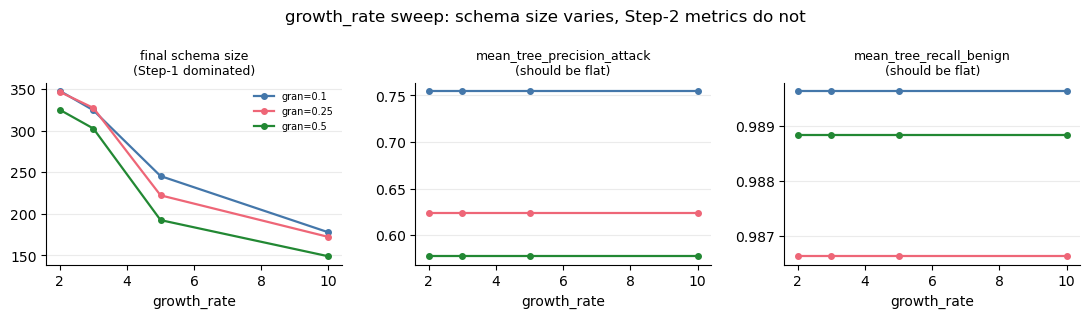

n_features  mean_tree_precision_attack  mean_tree_recall_benign
growth_rate gran                                                                 
2.0         0.10      347.80                       0.755                    0.990
            0.25      346.50                       0.623                    0.987
            0.50      325.00                       0.577                    0.989
3.0         0.10      324.40                       0.755                    0.990
            0.25      327.25                       0.623                    0.987
            0.50      302.50                       0.577                    0.989
5.0         0.10      245.40                       0.755                    0.990
            0.25      222.25                       0.623                    0.987
            0.50      192.50                       0.577                    0.989
10.0        0.10      177.80                       0.755                    0.990
            0.25      172.25                       0.623                    0.987
            0.50      149.00                       0.577                    0.989

In [6]:
gr_sweep = grid_df[GROWTH_RATE_SWEEP_MASK]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, (metric, label) in zip(axes, [
    ("n_features", "final schema size\n(Step-1 dominated)"),
    ("mean_tree_precision_attack", "mean_tree_precision_attack\n(should be flat)"),
    ("mean_tree_recall_benign", "mean_tree_recall_benign\n(should be flat)"),
]):
    for gran in GRANULARITIES:
        s = gr_sweep[gr_sweep.gran == gran].groupby("growth_rate")[metric].mean()
        ax.plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6,
                color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("growth_rate")
    strip_axes(ax)
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("growth_rate sweep: schema size varies, Step-2 metrics do not")
fig.tight_layout()
savefig(fig, "grid_growth_rate_orthogonality.png")
plt.show()

gr_sweep.groupby(["growth_rate", "gran"])[
    ["n_features", "mean_tree_precision_attack", "mean_tree_recall_benign"]
].mean().round(3)


### 2.2 max_depth vs. max_depth_attack: independent by construction, confirmed

Each depth axis was swept alone, holding the other tree's depth at its anchor. If the
two trees really are independent, `max_depth`'s sweep should move
`mean_tree_recall_benign` while leaving `mean_tree_precision_attack` untouched (it
wasn't even the tree being varied), and vice versa for `max_depth_attack`.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_two_tree_sweeps.png


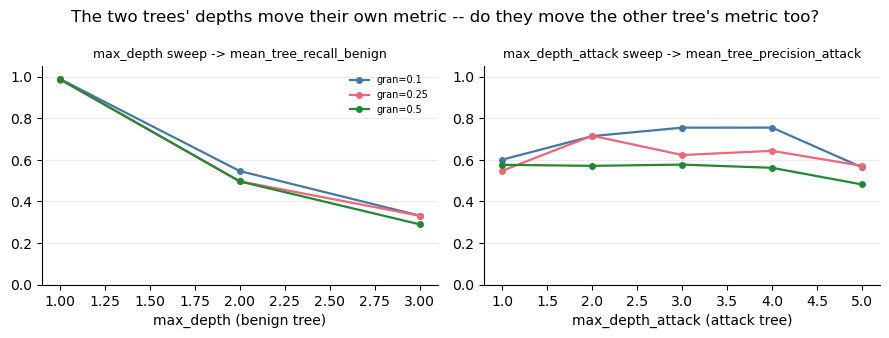

max_depth sweep -- does it also move mean_tree_precision_attack (should be flat, it's the OTHER tree)?
           mean_tree_recall_benign  mean_tree_precision_attack
max_depth                                                     
1                            0.989                         0.7
2                            0.528                         0.7
3                            0.326                         0.7

max_depth_attack sweep -- does it also move mean_tree_recall_benign (should be flat, it's the OTHER tree)?
                  mean_tree_precision_attack  mean_tree_recall_benign
max_depth_attack                                                     
1                                      0.585                    0.989
2                                      0.697                    0.989
3                                      0.700                    0.989
4                                      0.703                    0.989
5                                      0.555          

In [7]:
md_sweep = grid_df[MAX_DEPTH_SWEEP_MASK]
mda_sweep = grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
ax = axes[0]
for gran in GRANULARITIES:
    s = md_sweep[md_sweep.gran == gran].groupby("max_depth")["mean_tree_recall_benign"].mean()
    ax.plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
ax.set_title("max_depth sweep -> mean_tree_recall_benign", fontsize=9)
ax.set_xlabel("max_depth (benign tree)")
ax.set_ylim(0, 1.05)
strip_axes(ax)
ax.legend(frameon=False, fontsize=7)

ax = axes[1]
for gran in GRANULARITIES:
    s = mda_sweep[mda_sweep.gran == gran].groupby("max_depth_attack")["mean_tree_precision_attack"].mean()
    ax.plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
ax.set_title("max_depth_attack sweep -> mean_tree_precision_attack", fontsize=9)
ax.set_xlabel("max_depth_attack (attack tree)")
ax.set_ylim(0, 1.05)
strip_axes(ax)

fig.suptitle("The two trees' depths move their own metric -- do they move the other tree's metric too?")
fig.tight_layout()
savefig(fig, "grid_two_tree_sweeps.png")
plt.show()

print("max_depth sweep -- does it also move mean_tree_precision_attack (should be flat, it's the OTHER tree)?")
display_df = md_sweep.groupby("max_depth")[["mean_tree_recall_benign", "mean_tree_precision_attack"]].mean().round(3)
print(display_df)
print()
print("max_depth_attack sweep -- does it also move mean_tree_recall_benign (should be flat, it's the OTHER tree)?")
display_df2 = mda_sweep.groupby("max_depth_attack")[["mean_tree_precision_attack", "mean_tree_recall_benign"]].mean().round(3)
print(display_df2)


### 2.3 Cross-check: growth_rate x max_depth_attack jointly

A small, deliberately-kept cross-check (`growth_rate` in {2.0, 10.0} x
`max_depth_attack` in {1, 5}, `max_depth` held at its anchor) -- unlike the
single-tree script's later revision, which dropped its cross-check as redundant with
an already-exhaustively-verified grid, this one script keeps it because the algorithm
itself changed and the orthogonality argument hadn't been re-verified under two-tree
fitting before this run.

In [8]:
cross_check = grid_df[CROSS_CHECK_MASK]
cc_table = (
    cross_check.groupby(["growth_rate", "max_depth_attack"])[
        ["mean_tree_precision_attack", "mean_tree_recall_benign", "n_features"]
    ].mean().round(3)
)
print(cc_table)
print()
# Precision/recall should be identical across growth_rate at a fixed max_depth_attack
# (only n_features, the Step-1-driven schema size, should differ) -- if the growth_rate=2.0
# and growth_rate=10.0 rows disagree on precision/recall within a max_depth_attack
# level, that IS a real interaction and everything above needs revisiting.
precision_spread = cc_table.groupby("max_depth_attack")["mean_tree_precision_attack"].agg(lambda s: s.max() - s.min())
recall_spread = cc_table.groupby("max_depth_attack")["mean_tree_recall_benign"].agg(lambda s: s.max() - s.min())
print(f"Max precision_attack spread across growth_rate, per max_depth_attack: {precision_spread.max():.4f}")
print(f"Max recall_benign spread across growth_rate, per max_depth_attack: {recall_spread.max():.4f}")
assert precision_spread.max() < 0.01 and recall_spread.max() < 0.01, (
    "growth_rate x max_depth_attack interaction detected -- do not trust the "
    "one-axis-at-a-time sweeps above without investigating this"
)
print("Confirmed: growth_rate has no detectable effect on either Step-2 metric, even jointly with max_depth_attack.")


                              mean_tree_precision_attack  mean_tree_recall_benign  n_features
growth_rate max_depth_attack                                                                 
2.0         1                                      0.585                    0.989     344.250
            5                                      0.555                    0.989     345.625
10.0        1                                      0.585                    0.989     172.438
            5                                      0.555                    0.989     173.812

Max precision_attack spread across growth_rate, per max_depth_attack: 0.0000
Max recall_benign spread across growth_rate, per max_depth_attack: 0.0000
Confirmed: growth_rate has no detectable effect on either Step-2 metric, even jointly with max_depth_attack.


### 2.4 Temporal stability: how much does each swept axis's schema drift across windows?

Consecutive-window Jaccard similarity (win 0 vs 1, win 1 vs 2, ...), separately for
Step 1 (attack-leaning and benign-leaning contrast itemsets, from the `growth_rate`
sweep) and each Step-2 tree (benign tree's base features from the `max_depth` sweep,
attack tree's from the `max_depth_attack` sweep) -- each read at its own anchor point
for the other axes, same masks as section 2.1/2.2. `gran=0.5` has only one window
(nothing to compare it to) and is excluded.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_temporal_stability.png


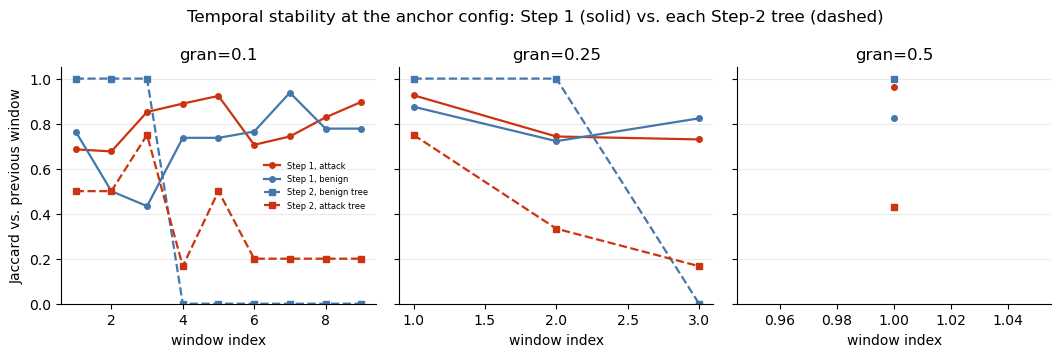

Mean consecutive-window Jaccard:
Step 1, attack: 0.812
Step 1, benign: 0.744
Step 2, benign tree: 0.462
Step 2, attack tree: 0.377


In [9]:
def jaccard(a: frozenset, b: frozenset) -> float:
    return len(a & b) / len(a | b) if (a or b) else 1.0


def consecutive_window_jaccard(df: pd.DataFrame, group_cols: list[str], set_cols: dict[str, str]) -> pd.DataFrame:
    """set_cols: {output_col_name: source_column_with_frozensets}. One row per
    (group, window, set_col) with that window's Jaccard vs. the previous window."""
    rows = []
    for key, sub in df.groupby(group_cols):
        sub = sub.sort_values("win_idx")
        prev = {}
        prev_win = None
        for _, r in sub.iterrows():
            if prev_win is not None:
                row = dict(zip(group_cols, key if isinstance(key, tuple) else (key,)))
                row["win_idx"] = r["win_idx"]
                for out_col, src_col in set_cols.items():
                    row[out_col] = jaccard(r[src_col], prev[src_col])
                rows.append(row)
            prev = {src_col: r[src_col] for src_col in set_cols.values()}
            prev_win = r["win_idx"]
    return pd.DataFrame(rows)


grans_with_multiple_windows = [g for g in GRANULARITIES if grid_df[grid_df.gran == g]["win_idx"].nunique() > 1]

step1_stability = consecutive_window_jaccard(
    grid_df[GROWTH_RATE_SWEEP_MASK & grid_df.gran.isin(grans_with_multiple_windows)],
    ["growth_rate", "gran"],
    {"jaccard_attack": "_contrast_itemset_set_attack", "jaccard_benign": "_contrast_itemset_set_benign"},
)
benign_tree_stability = consecutive_window_jaccard(
    grid_df[MAX_DEPTH_SWEEP_MASK & grid_df.gran.isin(grans_with_multiple_windows)],
    ["max_depth", "gran"],
    {"jaccard": "_tree_base_set_benign"},
)
attack_tree_stability = consecutive_window_jaccard(
    grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK & grid_df.gran.isin(grans_with_multiple_windows)],
    ["max_depth_attack", "gran"],
    {"jaccard": "_tree_base_set_attack"},
)

fig, axes = plt.subplots(1, len(grans_with_multiple_windows), figsize=(3.6 * len(grans_with_multiple_windows), 3.6), sharey=True, squeeze=False)
axes = axes[0]
for col_i, gran in enumerate(grans_with_multiple_windows):
    ax = axes[col_i]
    s1 = step1_stability[(step1_stability.gran == gran) & (step1_stability.growth_rate == STEP1_ANCHOR_GROWTH_RATE)]
    ax.plot(s1["win_idx"], s1["jaccard_attack"], marker="o", markersize=4, linewidth=1.6, color=ATTACK_COLOR, linestyle="-", label="Step 1, attack")
    ax.plot(s1["win_idx"], s1["jaccard_benign"], marker="o", markersize=4, linewidth=1.6, color=BENIGN_COLOR, linestyle="-", label="Step 1, benign")
    bt = benign_tree_stability[(benign_tree_stability.gran == gran) & (benign_tree_stability.max_depth == STEP2_ANCHOR_MAX_DEPTH)]
    ax.plot(bt["win_idx"], bt["jaccard"], marker="s", markersize=4, linewidth=1.6, color=BENIGN_COLOR, linestyle="--", label="Step 2, benign tree")
    at = attack_tree_stability[(attack_tree_stability.gran == gran) & (attack_tree_stability.max_depth_attack == STEP2_ANCHOR_MAX_DEPTH_ATTACK)]
    ax.plot(at["win_idx"], at["jaccard"], marker="s", markersize=4, linewidth=1.6, color=ATTACK_COLOR, linestyle="--", label="Step 2, attack tree")
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("window index")
    ax.set_ylim(0, 1.05)
    strip_axes(ax)
    if col_i == 0:
        ax.set_ylabel("Jaccard vs. previous window")
        ax.legend(frameon=False, fontsize=6)
fig.suptitle("Temporal stability at the anchor config: Step 1 (solid) vs. each Step-2 tree (dashed)")
fig.tight_layout()
savefig(fig, "grid_temporal_stability.png")
plt.show()

print("Mean consecutive-window Jaccard:")
print("Step 1, attack:", round(step1_stability[step1_stability.growth_rate == STEP1_ANCHOR_GROWTH_RATE]["jaccard_attack"].mean(), 3))
print("Step 1, benign:", round(step1_stability[step1_stability.growth_rate == STEP1_ANCHOR_GROWTH_RATE]["jaccard_benign"].mean(), 3))
print("Step 2, benign tree:", round(benign_tree_stability[benign_tree_stability.max_depth == STEP2_ANCHOR_MAX_DEPTH]["jaccard"].mean(), 3))
print("Step 2, attack tree:", round(attack_tree_stability[attack_tree_stability.max_depth_attack == STEP2_ANCHOR_MAX_DEPTH_ATTACK]["jaccard"].mean(), 3))


**Scope note**: the single-tree version of this notebook also had an age-based
feature-retention/lifecycle section here (separately tracking unfiltered Step-1
candidates, filtered survivors, and tree leaves as three levels, plus a per-feature
swimlane timeline). That's deliberately not rebuilt yet for the two-tree grid --
section 2.4 above already answers the main question it was built for (Step 1 is more
stable than Step 2, and now, which of the two trees is more stable), and rebuilding
the full 3-level age-based version cleanly for two independently-swept depth axes is
a real follow-up, not a quick port.

### 2.5 min_growth_rate_attack: independent of growth_rate and the benign side, by construction

`min_growth_rate_attack` only overrides the *attack-leaning* branch of Step 1's contrast
filter (`filter_contrast_survivors`); the benign branch never reads it, and
`test_filter_contrast_survivors_split_growth_rate_gates_attack_side_independently`
already proves this in isolation on synthetic data. Two consequences to check on the
real grid:

- **Benign side must be exactly flat** -- Step 1's benign survivors and the benign tree
  (fit only on benign-leaning survivors + numeric features) never see this threshold at
  all, so `n_contrast_benign`, `n_tree_leaves_benign`, `mean_tree_recall_benign` should
  show zero spread across `min_growth_rate_attack`, asserted below the same way section
  2.3's cross-check is.
- **Attack side is expected to move** -- raising the threshold changes which categorical
  predicates survive Step 1 on the attack-leaning side, which changes the feature set
  the attack tree is fit on. That's the whole point of the knob, not a bug; the plot
  below is a first look, section 3.3 characterizes it properly.

In [10]:
gra_sweep = grid_df[GROWTH_RATE_ATTACK_SWEEP_MASK]
benign_table = gra_sweep.groupby(["gran", "min_growth_rate_attack"], dropna=False)[
    ["n_contrast_benign", "n_tree_leaves_benign", "mean_tree_recall_benign"]
].mean().round(6)
print(benign_table)

benign_spread = benign_table.groupby("gran").agg(lambda s: s.max() - s.min())
print()
print("Max spread across min_growth_rate_attack, per gran:")
print(benign_spread)
assert (benign_spread.to_numpy() < 1e-9).all(), (
    "min_growth_rate_attack moved a benign-side metric -- filter_contrast_survivors's "
    "benign branch should never read this field, investigate before trusting anything below"
)
print("\nConfirmed: min_growth_rate_attack has zero effect on the benign side (Step 1 or the benign tree).")


                             n_contrast_benign  n_tree_leaves_benign  mean_tree_recall_benign
gran min_growth_rate_attack                                                                  
0.10 2.0                                 85.00                   1.0                 0.989633
     5.0                                 85.00                   1.0                 0.989633
     10.0                                85.00                   1.0                 0.989633
     NaN                                 85.00                   1.0                 0.989633
0.25 2.0                                 83.75                   1.0                 0.986632
     5.0                                 83.75                   1.0                 0.986632
     10.0                                83.75                   1.0                 0.986632
     NaN                                 83.75                   1.0                 0.986632
0.50 2.0                                 79.00              

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_growth_rate_attack_orthogonality.png


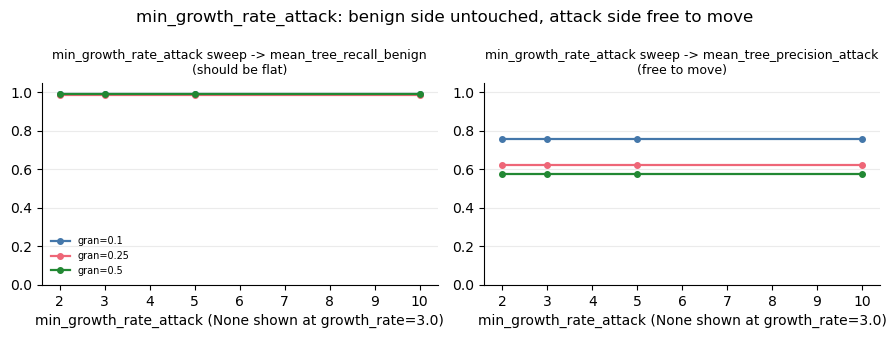

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
ax = axes[0]
for gran in GRANULARITIES:
    s = gra_sweep[gra_sweep.gran == gran].groupby("min_growth_rate_attack", dropna=False)["mean_tree_recall_benign"].mean()
    x = np.array([STEP1_ANCHOR_GROWTH_RATE if pd.isna(v) else v for v in s.index])
    order = np.argsort(x)
    ax.plot(x[order], s.values[order], marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
ax.set_title("min_growth_rate_attack sweep -> mean_tree_recall_benign\n(should be flat)", fontsize=9)
ax.set_xlabel("min_growth_rate_attack (None shown at growth_rate=3.0)")
ax.set_ylim(0, 1.05)
strip_axes(ax)
ax.legend(frameon=False, fontsize=7)

ax = axes[1]
for gran in GRANULARITIES:
    s = gra_sweep[gra_sweep.gran == gran].groupby("min_growth_rate_attack", dropna=False)["mean_tree_precision_attack"].mean()
    x = np.array([STEP1_ANCHOR_GROWTH_RATE if pd.isna(v) else v for v in s.index])
    order = np.argsort(x)
    ax.plot(x[order], s.values[order], marker="o", markersize=4, linewidth=1.6,
            color=gran_color_map(GRANULARITIES)[gran])
ax.set_title("min_growth_rate_attack sweep -> mean_tree_precision_attack\n(free to move)", fontsize=9)
ax.set_xlabel("min_growth_rate_attack (None shown at growth_rate=3.0)")
ax.set_ylim(0, 1.05)
strip_axes(ax)

fig.suptitle("min_growth_rate_attack: benign side untouched, attack side free to move")
fig.tight_layout()
savefig(fig, "grid_growth_rate_attack_orthogonality.png")
plt.show()


**Result**: benign side confirmed exactly flat (0.0 spread on `n_contrast_benign`,
`n_tree_leaves_benign`, `mean_tree_recall_benign` across every `min_growth_rate_attack`
value -- assert passes). The attack side's Step-1 survivor count does move as
expected -- `n_contrast_attack` falls from ~245 (`min_growth_rate_attack=2.0`) to ~156
(`5.0`) to ~101 (`10.0`), vs. ~236 at the `None` anchor (`growth_rate=3.0`'s own
reciprocal). Downstream, though, the attack tree's own metrics (`n_tree_leaves_attack`,
`mean_tree_recall_attack`, `mean_tree_precision_attack`) turn out to be exactly flat
too, not just "free to move" as predicted above -- see section 3.3 for the full effect
sweep and the likely mechanism.

## 3. Step 1: contrast-set mining -- growth_rate & coverage

### 3.1 Why Step 1 candidates get dropped

`contrast_stats_all.csv` has every candidate Step 1 considered; `contrast_survivors.csv`
has the ones that made it through. Diffing the two and re-deriving which threshold each
dropped candidate failed shows whether tightening `min_growth_rate` mostly removes
genuinely non-discriminative candidates (`growth_rate_too_close_to_1`, expected and
healthy) or starts cutting into candidates that look discriminative but lack coverage.
Shown per granularity at its first window (`win_idx=0`); the `growth_rate` sweep is
already fixed at one `(max_depth, max_depth_attack)` anchor (section 2.1 confirmed
Step 2 doesn't affect this), so there's nothing else to hold constant.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_drop_reasons.png


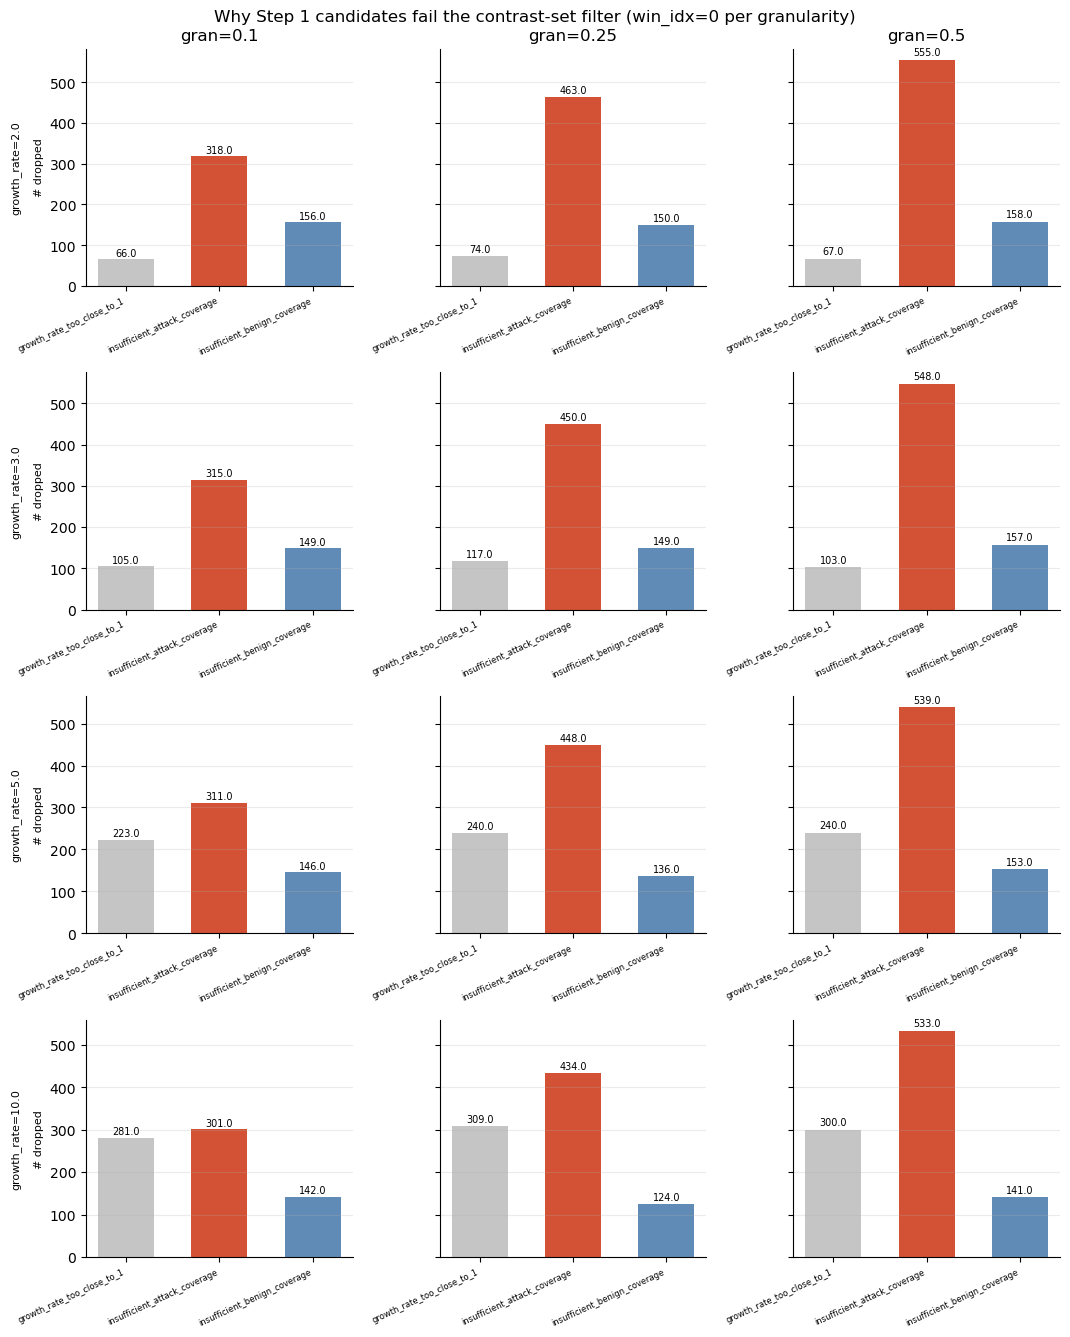

In [12]:
reason_order = ["growth_rate_too_close_to_1", "insufficient_attack_coverage", "insufficient_benign_coverage", "other"]
reason_colors = [NEUTRAL_COLOR, ATTACK_COLOR, BENIGN_COLOR, "#DDCC77"]

gr_rows = grid_df[GROWTH_RATE_SWEEP_MASK]

fig, axes = plt.subplots(
    len(GROWTH_RATES), len(GRANULARITIES),
    figsize=(3.6 * len(GRANULARITIES), 3.4 * len(GROWTH_RATES)),
    sharey="row",
)
for row_i, gr in enumerate(GROWTH_RATES):
    for col_i, gran in enumerate(GRANULARITIES):
        ax = axes[row_i, col_i]
        row = gr_rows[(gr_rows.growth_rate == gr) & (gr_rows.gran == gran) & (gr_rows.win_idx == 0)].iloc[0]
        stats_all = pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv")
        survivors = pd.read_csv(row["mining_dir"] / "contrast_survivors.csv")
        dropped = stats_all[~stats_all["itemset"].isin(set(survivors["itemset"]))].copy()

        inv_threshold = 1.0 / gr if gr > 0 else float("inf")
        attack_leaning = dropped["growth_rate"] >= gr
        benign_leaning = (dropped["confidence_benign"] > 0) & (dropped["growth_rate"] <= inv_threshold)
        conditions = [
            ~(attack_leaning | benign_leaning),
            attack_leaning & (dropped["confidence_attack"] < row["min_attack_coverage"]),
            benign_leaning & (dropped["confidence_benign"] < row["min_benign_coverage"]),
        ]
        dropped["reason"] = np.select(conditions, reason_order[:3], default="other")
        counts = dropped["reason"].value_counts().reindex(reason_order).dropna()

        x = np.arange(len(counts))
        ax.bar(x, counts.values, color=reason_colors[: len(counts)], alpha=0.85, width=0.6)
        for i, v in enumerate(counts.values):
            ax.text(i, v + counts.values.max() * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=7)
        ax.set_xticks(x)
        ax.set_xticklabels(counts.index, rotation=25, ha="right", fontsize=6)
        if row_i == 0:
            ax.set_title(f"gran={gran:g}")
        if col_i == 0:
            ax.set_ylabel(f"growth_rate={gr}\n\n# dropped", fontsize=8)
        strip_axes(ax)

fig.suptitle("Why Step 1 candidates fail the contrast-set filter (win_idx=0 per granularity)")
fig.tight_layout()
savefig(fig, "grid_drop_reasons.png")
plt.show()


### Step 1's feasible region, directly

Unlike Step 2's precision/recall floors (two *independent* thresholds -- a rectangle),
Step 1's selection metric is `growth_rate = attack_support / benign_support`, a
**ratio** of two per-class recalls (`confidence_attack`/`confidence_benign` in the raw
stats -- `P(fires | attack)` and `P(fires | benign)`, not precision at all; the real
`precision_attack` column is computed but never gated on, diagnostic only). A ratio
threshold is a *ray through the origin* in (attack_support, benign_support) space, not
an axis-aligned line -- `growth_rate >= threshold` is everything below the line
`y = x / threshold`; `growth_rate <= 1/min_growth_rate` (the benign-leaning direction)
is everything above `y = min_growth_rate * x`. Each side also needs its own coverage
floor (`min_attack_coverage`/`min_benign_coverage`) to survive.

`contrast_stats_all.csv` doesn't depend on growth_rate/coverage at all
(`compute_predicate_contrast_stats` takes no threshold arguments) -- the *candidate*
scatter below is identical across growth_rate values; only which points are colored
"survivor" and where the boundary rays sit changes. Shown at `gran=0.1`, `win_idx=0`
(most candidates, same representative window `3.1` uses).

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_step1_feasible_region.png


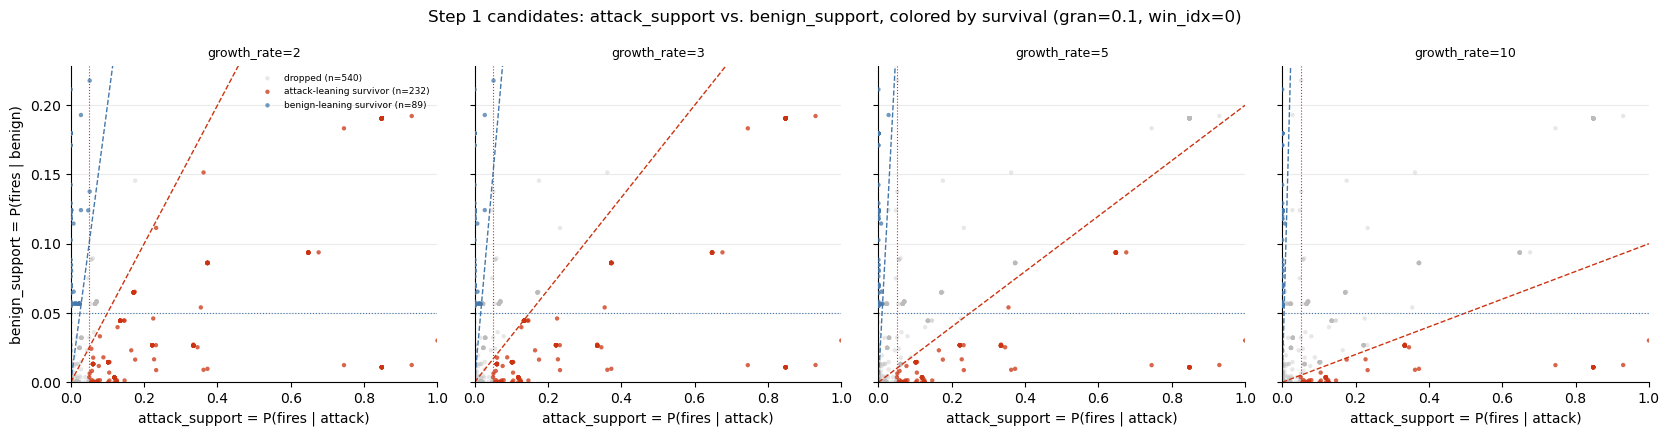

In [13]:
import ast as _ast

_gran_sel, _win_sel = 0.1, 0
_anchor_row = grid_df[
    (grid_df.growth_rate == STEP1_ANCHOR_GROWTH_RATE) & (grid_df.gran == _gran_sel) & (grid_df.win_idx == _win_sel)
    & GROWTH_RATE_SWEEP_MASK
].iloc[0]
stats_all = pd.read_csv(_anchor_row["mining_dir"] / "contrast_stats_all.csv")
stats_all["itemset"] = stats_all["itemset"].apply(_ast.literal_eval)

xmax = min(1.0, stats_all["confidence_attack"].quantile(0.98) * 1.2)
ymax = min(1.0, stats_all["confidence_benign"].quantile(0.98) * 1.2)

fig, axes = plt.subplots(1, len(GROWTH_RATES), figsize=(4.2 * len(GROWTH_RATES), 4.4), sharex=True, sharey=True)
for ax, gr in zip(axes, GROWTH_RATES):
    row = grid_df[
        (grid_df.growth_rate == gr) & (grid_df.gran == _gran_sel) & (grid_df.win_idx == _win_sel)
        & GROWTH_RATE_SWEEP_MASK
    ].iloc[0]
    survivors = pd.read_csv(row["mining_dir"] / "contrast_survivors.csv")
    survivors["itemset"] = survivors["itemset"].apply(_ast.literal_eval)
    survivor_itemsets = set(survivors["itemset"])

    is_survivor = stats_all["itemset"].isin(survivor_itemsets)
    attack_leaning = stats_all["growth_rate"] >= gr
    category = np.select(
        [is_survivor & attack_leaning, is_survivor & ~attack_leaning],
        ["attack-leaning survivor", "benign-leaning survivor"],
        default="dropped",
    )

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    for cat, color, alpha, z in [
        ("dropped", NEUTRAL_COLOR, 0.35, 1),
        ("attack-leaning survivor", ATTACK_COLOR, 0.75, 3),
        ("benign-leaning survivor", BENIGN_COLOR, 0.75, 3),
    ]:
        mask = category == cat
        ax.scatter(
            stats_all.loc[mask, "confidence_attack"], stats_all.loc[mask, "confidence_benign"],
            s=10, alpha=alpha, color=color, edgecolor="none", zorder=z,
            label=f"{cat} (n={int(mask.sum())})",
        )

    x_line = np.linspace(0, xmax, 200)
    ax.plot(x_line, x_line / gr, color=ATTACK_COLOR, linestyle="--", linewidth=1, zorder=2)
    ax.plot(x_line, x_line * gr, color=BENIGN_COLOR, linestyle="--", linewidth=1, zorder=2)
    ax.axvline(row["min_attack_coverage"], color=ATTACK_COLOR, linestyle=":", linewidth=0.8, zorder=2)
    ax.axhline(row["min_benign_coverage"], color=BENIGN_COLOR, linestyle=":", linewidth=0.8, zorder=2)

    ax.set_title(f"growth_rate={gr:g}", fontsize=9)
    ax.set_xlabel("attack_support = P(fires | attack)")
    strip_axes(ax)
axes[0].set_ylabel("benign_support = P(fires | benign)")
axes[0].legend(frameon=False, fontsize=6.5, loc="upper right")
fig.suptitle("Step 1 candidates: attack_support vs. benign_support, colored by survival "
             f"(gran={_gran_sel:g}, win_idx={_win_sel})")
fig.tight_layout()
savefig(fig, "grid_step1_feasible_region.png")
plt.show()

**Result**: at `gran=0.1`/`win_idx=0` (861 candidates total), raising `growth_rate`
from 2 to 10 mainly *widens the middle wedge* -- candidates too weakly class-skewed to
clear either ray -- rather than changing how many fail on coverage alone: middle-wedge
drops grow 66 -> 105 -> 223 -> 281 as `growth_rate` rises, while coverage-only drops
stay roughly flat (~443-474) across every value, since the coverage floor never reads
`growth_rate` at all. Survivor counts on both sides shrink together as the threshold
tightens (attack: 232 -> 217 -> 111 -> 72; benign: 89 -> 75 -> 70 -> 65) -- the benign
side shrinks too even though `min_growth_rate` is nominally "its own" threshold,
because raising it tightens the reciprocal (`1/growth_rate`) bound on that side as well.
Both `attack_support`/`benign_support` are heavily right-skewed across all candidates
(median 0.009 / 0.001 vs. mean 0.123 / 0.042) -- most candidates barely fire on
anything; survivors are the sparse population out near the axes, not a general
scatter.

### 3.2 Coverage effect: min_attack_coverage / min_benign_coverage

Each swept one axis at a time (holding the other at its 0.05 default), at the same
Step-2 anchor as the growth_rate sweep. Same structural metrics as everywhere else in
this notebook -- structural only, not model precision/recall/FPR.

In [14]:
coverage_df = grid_df[COVERAGE_SWEEP_MASK]
print(f"{len(coverage_df)} coverage-sweep runs: "
      f"min_attack_coverage={sorted(coverage_df['min_attack_coverage'].unique())}, "
      f"min_benign_coverage={sorted(coverage_df['min_benign_coverage'].unique())}")


112 coverage-sweep runs: min_attack_coverage=[0.0, 0.05, 0.15, 0.3], min_benign_coverage=[0.0, 0.05, 0.15, 0.3]


  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_coverage_effect.png


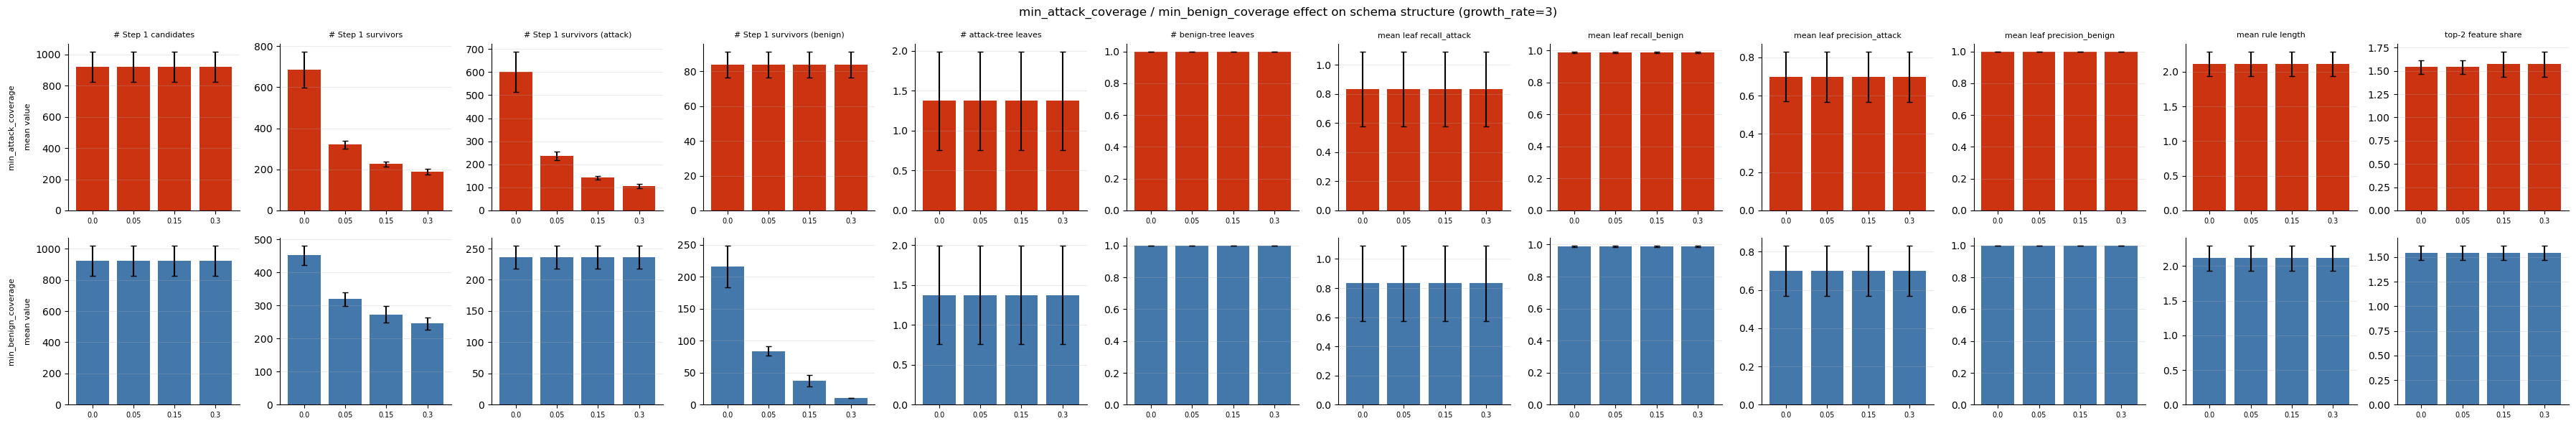

In [15]:
fig, axes = plt.subplots(2, len(STRUCTURAL_METRICS), figsize=(3.0 * len(STRUCTURAL_METRICS), 6.0))
for col_i, (metric, label) in enumerate(STRUCTURAL_METRICS):
    ax = axes[0, col_i]
    ac_rows = coverage_df[coverage_df["min_benign_coverage"] == STEP1_ANCHOR_BENIGN_COVERAGE]
    ac_stats = ac_rows.groupby("min_attack_coverage")[metric].agg(["mean", "std"])
    ax.bar(ac_stats.index.astype(str), ac_stats["mean"], yerr=ac_stats["std"].fillna(0), color=ATTACK_COLOR, capsize=3)
    ax.set_title(label, fontsize=8)
    ax.tick_params(axis="x", labelsize=7)
    if col_i == 0:
        ax.set_ylabel("min_attack_coverage\n\nmean value", fontsize=8)
    strip_axes(ax)

    ax = axes[1, col_i]
    bc_rows = coverage_df[coverage_df["min_attack_coverage"] == STEP1_ANCHOR_ATTACK_COVERAGE]
    bc_stats = bc_rows.groupby("min_benign_coverage")[metric].agg(["mean", "std"])
    ax.bar(bc_stats.index.astype(str), bc_stats["mean"], yerr=bc_stats["std"].fillna(0), color=BENIGN_COLOR, capsize=3)
    ax.tick_params(axis="x", labelsize=7)
    if col_i == 0:
        ax.set_ylabel("min_benign_coverage\n\nmean value", fontsize=8)
    strip_axes(ax)

fig.suptitle(f"min_attack_coverage / min_benign_coverage effect on schema structure (growth_rate={STEP1_ANCHOR_GROWTH_RATE:g})")
fig.tight_layout()
savefig(fig, "grid_coverage_effect.png")
plt.show()


### 3.3 min_growth_rate_attack: the attack-facing contrast threshold

Swept alone at the Step-1/Step-2 anchor (`growth_rate=3.0`, `max_depth=1`,
`max_depth_attack=3`) -- section 2.5 already confirmed the benign side is untouched;
this looks at what raising the attack-facing threshold does to Step 1's attack
survivors and, downstream, the attack tree fit on top of them. The `None`-anchor row
(`growth_rate=3.0` itself) is included as the "no split" reference point alongside
the three explicit values (2.0, 5.0, 10.0).

In [16]:
gra_sweep_full = grid_df[GROWTH_RATE_ATTACK_SWEEP_MASK]
gra_table = gra_sweep_full.groupby("min_growth_rate_attack", dropna=False)[
    [m for m, _ in STRUCTURAL_METRICS if "benign" not in m]
].agg(["mean", "std"]).round(3)
gra_table


n_step1_candidates         n_contrast         n_contrast_attack         n_tree_leaves_attack        mean_tree_recall_attack        mean_tree_precision_attack         \
                                     mean     std       mean     std              mean     std                 mean    std                    mean    std                       mean    std   
min_growth_rate_attack                                                                                                                                                                        
2.0                               922.375  97.158    329.438  20.047           245.500  17.791                1.375  0.619                   0.833  0.258                        0.7  0.131   
5.0                               922.375  97.158    240.312  40.355           156.375  37.808                1.375  0.619                   0.833  0.258                        0.7  0.131   
10.0                              922.375  97.158    185.438  25.208           101.500  22.707                1.375  0.619                   0.833  0.258                        0.7  0.131   
NaN                               922.375  97.158    320.000  20.337           236.062  18.664                1.375  0.619                   0.833  0.258                        0.7  0.131   

                       mean_rule_length       top2_feature_share         
                                   mean   std               mean    std  
min_growth_rate_attack                                                   
2.0                               2.115  0.18              1.542  0.075  
5.0                               2.115  0.18              1.542  0.075  
10.0                              2.115  0.18              1.542  0.075  
NaN                               2.115  0.18              1.542  0.075

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_growth_rate_attack_effect.png


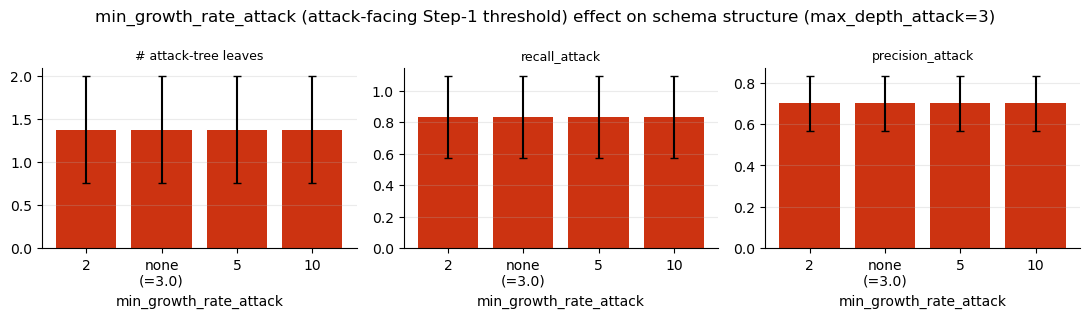

In [17]:
_gra_sort_key = lambda v: STEP1_ANCHOR_GROWTH_RATE if pd.isna(v) else v
_gra_label = lambda v: "none\n(=3.0)" if pd.isna(v) else f"{v:g}"

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, metric, label in zip(axes,
    ["n_tree_leaves_attack", "mean_tree_recall_attack", "mean_tree_precision_attack"],
    ["# attack-tree leaves", "recall_attack", "precision_attack"],
):
    stats = gra_sweep_full.groupby("min_growth_rate_attack", dropna=False)[metric].agg(["mean", "std"])
    stats = stats.sort_index(key=lambda idx: idx.map(_gra_sort_key))
    labels = [_gra_label(v) for v in stats.index]
    ax.bar(labels, stats["mean"], yerr=stats["std"].fillna(0), color=ATTACK_COLOR, capsize=3)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("min_growth_rate_attack")
    strip_axes(ax)
fig.suptitle(f"min_growth_rate_attack (attack-facing Step-1 threshold) effect on schema structure (max_depth_attack={STEP2_ANCHOR_MAX_DEPTH_ATTACK})")
fig.tight_layout()
savefig(fig, "grid_growth_rate_attack_effect.png")
plt.show()


**Result**: `min_growth_rate_attack` has **zero** measured effect on every attack-tree
metric -- `n_tree_leaves_attack` (1.375), `mean_tree_recall_attack` (0.833),
`mean_tree_precision_attack` (0.700), `mean_rule_length` (2.115), and
`top2_feature_share` (1.542) are identical, to three decimals, at `2.0`, `5.0`, `10.0`,
and the `None` anchor. What *does* move is Step 1's own attack-survivor count
(`n_contrast_attack`, part of the final schema): 245.5 -> 156.4 -> 101.5 as the
threshold rises from 2.0 to 10.0, vs. 236.1 at the `None`/`3.0` anchor. Likely
mechanism: at `max_depth_attack=3` the attack tree only ever ends up choosing ~1-2
features regardless (`top2_feature_share` ~1.54 out of ~1.4 leaves), and those
strongest predicates already clear even the strictest Step-1 bar (`10.0`) -- pruning
the *weaker* candidates the tree was never going to pick anyway costs nothing.
Practically: `min_growth_rate_attack` is a second, independent "free" schema-size
lever alongside `growth_rate` itself (section 2.1) -- raising it shrinks the final
schema (fewer Step-1 attack-survivor features) with no measured precision/recall cost,
at this `max_depth_attack=3` anchor.

## 4. Step 2: two independent decision trees

Section 2.2 already showed the headline numbers; this section is the detailed
per-metric view of each axis, the same treatment section 3 gives Step 1.
`min_samples_leaf` is not swept in this grid at all -- negligible on every
structural metric in the prior single-tree analysis
(`summaries/ATTRIBUTE_MINING_PARAMETER_ANALYSIS.md`), fixed at 20 everywhere here
rather than re-tested.

### 4.1 max_depth: the benign-facing tree

Recall_benign was cleanly monotonic in the prior single-tree analysis (best
shallow), so this sweep confirms that rather than searching for a hidden peak.

In [18]:
md_sweep_full = grid_df[MAX_DEPTH_SWEEP_MASK]
md_table = md_sweep_full.groupby("max_depth")[
    [m for m, _ in STRUCTURAL_METRICS if "attack" not in m]
].agg(["mean", "std"]).round(3)
md_table


n_step1_candidates         n_contrast         n_contrast_benign        n_tree_leaves_benign       mean_tree_recall_benign        mean_tree_precision_benign        mean_rule_length         \
                        mean     std       mean     std              mean    std                 mean   std                    mean    std                       mean    std             mean    std   
max_depth                                                                                                                                                                                              
1                    922.375  97.158      320.0  20.337            83.938  7.505                1.000  0.00                   0.989  0.005                      1.000  0.000            2.115  0.180   
2                    922.375  97.158      320.0  20.337            83.938  7.505                1.938  0.25                   0.528  0.123                      0.999  0.002            2.105  0.179   
3                    922.375  97.158      320.0  20.337            83.938  7.505                3.062  0.25                   0.326  0.021                      1.000  0.000            2.375  0.201   

          top2_feature_share         
                        mean    std  
max_depth                            
1                      1.542  0.075  
2                      1.678  0.039  
3                      1.751  0.053

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_max_depth_benign_effect.png


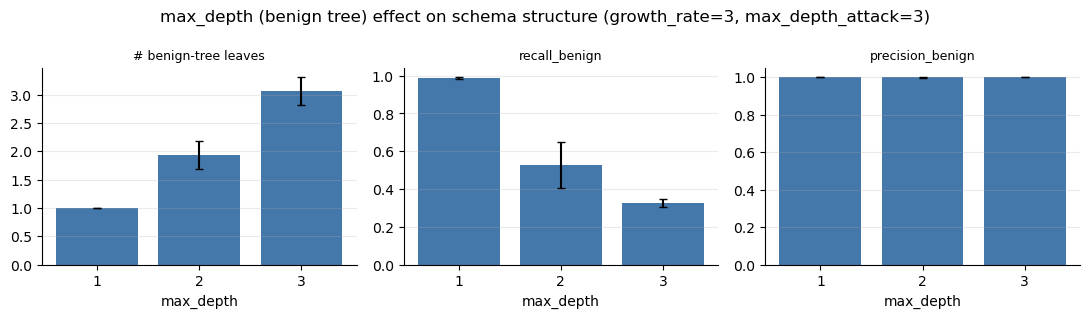

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, metric, label in zip(axes,
    ["n_tree_leaves_benign", "mean_tree_recall_benign", "mean_tree_precision_benign"],
    ["# benign-tree leaves", "recall_benign", "precision_benign"],
):
    stats = md_sweep_full.groupby("max_depth")[metric].agg(["mean", "std"])
    ax.bar(stats.index.astype(str), stats["mean"], yerr=stats["std"].fillna(0), color=BENIGN_COLOR, capsize=3)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("max_depth")
    strip_axes(ax)
fig.suptitle(f"max_depth (benign tree) effect on schema structure (growth_rate={STEP1_ANCHOR_GROWTH_RATE:g}, max_depth_attack={STEP2_ANCHOR_MAX_DEPTH_ATTACK})")
fig.tight_layout()
savefig(fig, "grid_max_depth_benign_effect.png")
plt.show()


**Result**: `recall_benign` crashes 0.989 -> 0.528 -> 0.326 as `max_depth` goes
1 -> 2 -> 3, confirming the single-tree finding under two-tree fitting -- shallower
is unambiguously better for the benign tree, no reason to search deeper than the
tested range.

### 4.2 max_depth_attack: the attack-facing tree

Precision_attack was non-monotonic in the single-tree analysis (peaked at depth 3,
worse at 1 and 5, with 2 and 4 never tested) -- this sweep fills in that gap.

In [20]:
mda_sweep_full = grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK]
mda_table = mda_sweep_full.groupby("max_depth_attack")[
    [m for m, _ in STRUCTURAL_METRICS if "benign" not in m]
].agg(["mean", "std"]).round(3)
mda_table


n_step1_candidates         n_contrast         n_contrast_attack         n_tree_leaves_attack        mean_tree_recall_attack        mean_tree_precision_attack         \
                               mean     std       mean     std              mean     std                 mean    std                    mean    std                       mean    std   
max_depth_attack                                                                                                                                                                        
1                           922.375  97.158      320.0  20.337           236.062  18.664                1.000  0.000                   0.999  0.005                      0.585  0.075   
2                           922.375  97.158      320.0  20.337           236.062  18.664                1.125  0.342                   0.937  0.171                      0.697  0.095   
3                           922.375  97.158      320.0  20.337           236.062  18.664                1.375  0.619                   0.833  0.258                      0.700  0.131   
4                           922.375  97.158      320.0  20.337           236.062  18.664                1.625  0.885                   0.755  0.294                      0.703  0.158   
5                           922.375  97.158      320.0  20.337           236.062  18.664                2.375  0.957                   0.476  0.173                      0.555  0.125   

                 mean_rule_length        top2_feature_share         
                             mean    std               mean    std  
max_depth_attack                                                    
1                           1.000  0.000              1.000  0.000  
2                           1.521  0.057              1.500  0.061  
3                           2.115  0.180              1.542  0.075  
4                           2.656  0.215              1.631  0.195  
5                           3.407  0.186              1.854  0.179

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_max_depth_attack_effect.png


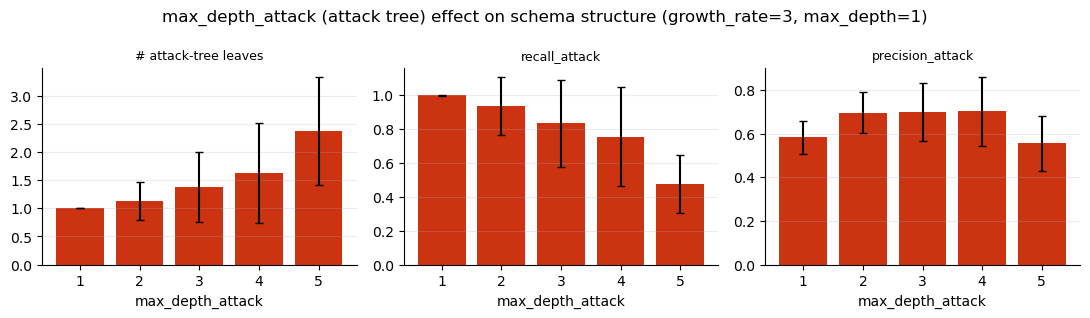

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, metric, label in zip(axes,
    ["n_tree_leaves_attack", "mean_tree_recall_attack", "mean_tree_precision_attack"],
    ["# attack-tree leaves", "recall_attack", "precision_attack"],
):
    stats = mda_sweep_full.groupby("max_depth_attack")[metric].agg(["mean", "std"])
    ax.bar(stats.index.astype(str), stats["mean"], yerr=stats["std"].fillna(0), color=ATTACK_COLOR, capsize=3)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("max_depth_attack")
    strip_axes(ax)
fig.suptitle(f"max_depth_attack (attack tree) effect on schema structure (growth_rate={STEP1_ANCHOR_GROWTH_RATE:g}, max_depth={STEP2_ANCHOR_MAX_DEPTH})")
fig.tight_layout()
savefig(fig, "grid_max_depth_attack_effect.png")
plt.show()


**Result**: `precision_attack` is 0.585 -> 0.697 -> 0.700 -> 0.703 -> 0.555 for
depths 1 through 5 -- wider and flatter than the earlier {1,3,5}-only data suggested:
depths 2, 3, and 4 are essentially tied (~0.70), only the extremes (1 and 5) are
clearly worse. There isn't a sharp peak to defend a single "best" depth over its
neighbors -- any of {2,3,4} is a defensible choice on precision alone; `n_tree_leaves_attack`
grows steadily with depth (1.0 -> 1.1 -> 1.4 -> 1.6 -> 2.4), so the shallowest of that
plateau (`max_depth_attack=2`) is marginally simpler for the same precision.

### 4.3 class_weight

In [22]:
cw_sweep = grid_df[CLASS_WEIGHT_SWEEP_MASK]
print(f"{len(cw_sweep)} runs: class_weight={sorted(cw_sweep['class_weight'].astype(str).unique())}")
cw_table = cw_sweep.groupby(cw_sweep["class_weight"].fillna("none"))[
    ["n_tree_leaves_attack", "n_tree_leaves_benign", "mean_tree_recall_attack", "mean_tree_recall_benign",
     "mean_tree_precision_attack", "mean_tree_precision_benign"]
].mean().round(3)
cw_table


32 runs: class_weight=['None', 'balanced']


,n_tree_leaves_attack,n_tree_leaves_benign,mean_tree_recall_attack,mean_tree_recall_benign,mean_tree_precision_attack,mean_tree_precision_benign
class_weight,,,,,,
balanced,1.375,1.0,0.833,0.989,0.700,1.000
none,5.312,1.0,0.197,0.993,0.531,0.999


**Result**: `class_weight="none"` still fragments the attack tree (5.3 leaves vs.
1.4, recall_attack 0.197 vs. 0.833) as in the single-tree analysis, but under
two-tree fitting it now also costs real precision_attack (0.531 vs. 0.700) --
"balanced" was previously framed as purity-neutral; at this depth it isn't quite.
Benign tree is unaffected either way, consistent with `max_depth=1`'s trivial
2-leaf structure leaving little for `class_weight` to change. Keep
`class_weight="balanced"` as the default -- it was already the better choice on
efficiency grounds, this adds a precision reason too.

## 5. Combined outcome & recommended config

### 5.1 Final schema size

`n_features` = Step-1 survivors + both trees' leaves combined. growth_rate is still
the dominant lever (Step-1 survivor count); the two tree depths only ever contribute
a handful of leaves each, so their effect on total size is minor by comparison.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_final_schema_size.png


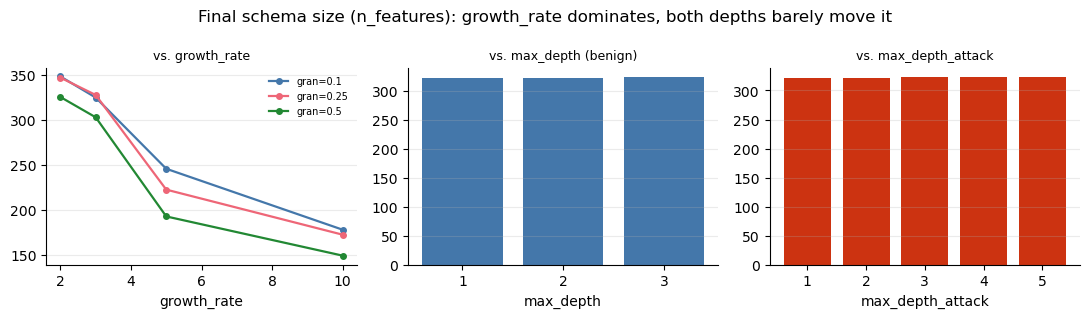

growth_rate sweep:
              mean   std  min  max
growth_rate                       
2.0          344.6  23.5  298  382
3.0          322.4  20.3  290  357
5.0          233.0  39.7  182  308
10.0         172.8  24.0  139  211


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
gr_rows = grid_df[GROWTH_RATE_SWEEP_MASK]
for gran in GRANULARITIES:
    s = gr_rows[gr_rows.gran == gran].groupby("growth_rate")["n_features"].mean()
    axes[0].plot(s.index, s.values, marker="o", markersize=4, linewidth=1.6, color=gran_color_map(GRANULARITIES)[gran], label=f"gran={gran:g}")
axes[0].set_title("vs. growth_rate", fontsize=9)
axes[0].set_xlabel("growth_rate")
axes[0].legend(frameon=False, fontsize=7)
strip_axes(axes[0])

md_rows = grid_df[MAX_DEPTH_SWEEP_MASK]
s = md_rows.groupby("max_depth")["n_features"].mean()
axes[1].bar(s.index.astype(str), s.values, color=BENIGN_COLOR)
axes[1].set_title("vs. max_depth (benign)", fontsize=9)
axes[1].set_xlabel("max_depth")
strip_axes(axes[1])

mda_rows = grid_df[MAX_DEPTH_ATTACK_SWEEP_MASK]
s = mda_rows.groupby("max_depth_attack")["n_features"].mean()
axes[2].bar(s.index.astype(str), s.values, color=ATTACK_COLOR)
axes[2].set_title("vs. max_depth_attack", fontsize=9)
axes[2].set_xlabel("max_depth_attack")
strip_axes(axes[2])

fig.suptitle("Final schema size (n_features): growth_rate dominates, both depths barely move it")
fig.tight_layout()
savefig(fig, "grid_final_schema_size.png")
plt.show()

print("growth_rate sweep:")
print(gr_rows.groupby("growth_rate")["n_features"].agg(["mean", "std", "min", "max"]).round(1))


### 5.2 Mined features by source_label, per window

Same window-composition view as before: does the schema stay attack/benign-balanced
over time, at the `growth_rate` anchor.

  [skip] Loading alert_groups from existing ../../../artifacts/cache/cscas/groups/cscas_pregrouped/alert_groups/alert_groups_raw.json


  Loaded 1395324 alert_groups from cache.


  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_feature_source_label_by_window.png


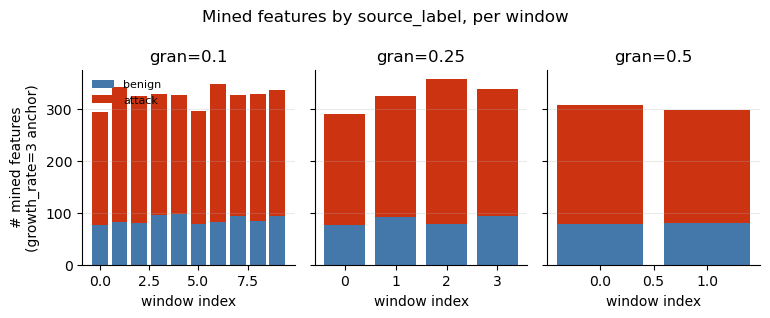

n_features_attack  n_features_benign
gran win_idx                                      
0.10 0                    218.0               76.0
     1                    260.0               82.0
     2                    244.0               80.0
     3                    232.0               95.0
     4                    229.0               97.0
     5                    217.0               78.0
     6                    266.0               82.0
     7                    233.0               93.0
     8                    243.0               84.0
     9                    242.0               93.0
0.25 0                    214.0               76.0
     1                    233.0               91.0
     2                    279.0               78.0
     3                    244.0               94.0
0.50 0                    228.0               79.0
     1                    217.0               81.0

In [24]:
from thesis.pipeline.pipeline import compute_window_bounds, load_or_build_alert_groups
from thesis.experiments._shared import labels_and_mask

_cache_dir = Path("../../../artifacts/cache/cscas/groups/cscas_pregrouped")
_alert_groups = load_or_build_alert_groups(SCENARIO, _cache_dir)
_alert_groups.sort(key=lambda t: t.start_ts or "")

gr_anchor_rows = grid_df[GROWTH_RATE_SWEEP_MASK & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)]
feat_label_by_window = gr_anchor_rows.groupby(["gran", "win_idx"])[["n_features_attack", "n_features_benign"]].mean().reset_index()

fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(2.6 * len(GRANULARITIES), 3.2), sharey=True)
for ax, gran in zip(axes, GRANULARITIES):
    sub = feat_label_by_window[feat_label_by_window.gran == gran].sort_values("win_idx")
    ax.bar(sub["win_idx"], sub["n_features_benign"], color=BENIGN_COLOR, label="benign")
    ax.bar(sub["win_idx"], sub["n_features_attack"], bottom=sub["n_features_benign"], color=ATTACK_COLOR, label="attack")
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("window index")
    strip_axes(ax)
axes[0].set_ylabel(f"# mined features\n(growth_rate={STEP1_ANCHOR_GROWTH_RATE:g} anchor)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Mined features by source_label, per window")
fig.tight_layout()
savefig(fig, "grid_feature_source_label_by_window.png")
plt.show()

feat_label_by_window.set_index(["gran", "win_idx"]).round(2)


### 5.3 Feasible region & recommended config

Under single-tree Step 2, this section built a scatter plot of `precision_attack` vs.
`recall_benign` with a shared `max_depth` driving both axes -- and found 0/36 configs
clearing both a precision and a recall floor at once, because the two metrics moved in
opposite directions under one shared depth. That's no longer the right framing: section
2.2 already confirmed `max_depth` and `max_depth_attack` don't interact, so the two
metrics are now independently optimizable -- there's no scatter to search, just two
separate 1-D choices (section 4.1's `max_depth`, section 4.2's `max_depth_attack`) plus
`growth_rate`/coverage for schema size on top.

Floors used here: `mean_tree_precision_attack >= 0.65` (lowered from the single-tree
analysis's 0.7 -- section 4.2 found precision now plateaus at ~0.70 for depths 2-4
rather than peaking sharply, so 0.7 sat right on the ceiling instead of comfortably
below it) and `mean_tree_recall_benign >= 0.5` (unchanged).

The plot below reconstructs the old scatter/bubble style rather than two separate bar charts -- since `max_depth` and `max_depth_attack` are proven independent (section 2.2/2.3), a `(max_depth, max_depth_attack)` combo's precision/recall can be read straight off the two 1-D sweeps and combined as if the full cross product had been mined, even though it wasn't. Bubble size (schema size) is similarly assembled from three independently-measured, additive pieces at the `growth_rate=3.0` anchor: Step-1 survivors + benign-tree leaves + attack-tree leaves.

In [25]:
PRECISION_ATTACK_FLOOR = 0.65
RECALL_BENIGN_FLOOR = 0.5

# max_depth (benign) is trivially resolved -- monotonic, pick the shallowest.
best_max_depth = (
    md_sweep_full.groupby("max_depth")["mean_tree_recall_benign"].mean()
    .pipe(lambda s: s[s >= RECALL_BENIGN_FLOOR]).index.min()
)
feasible_max_depths = sorted(
    md_sweep_full.groupby("max_depth")["mean_tree_recall_benign"].mean()
    .pipe(lambda s: s[s >= RECALL_BENIGN_FLOOR]).index
)
print(f"max_depth values clearing recall_benign >= {RECALL_BENIGN_FLOOR}: {feasible_max_depths}")
print(f"-> shallowest (recommended): max_depth={best_max_depth}")

# max_depth_attack: which values clear the precision floor, and pick the smallest
# (cheapest/most stable) among them since section 4.2 found no sharp peak.
mda_precision = mda_sweep_full.groupby("max_depth_attack")["mean_tree_precision_attack"].mean()
feasible_max_depths_attack = sorted(mda_precision[mda_precision >= PRECISION_ATTACK_FLOOR].index)
print(f"\nmax_depth_attack values clearing precision_attack >= {PRECISION_ATTACK_FLOOR}: {feasible_max_depths_attack}")
best_max_depth_attack = min(feasible_max_depths_attack) if feasible_max_depths_attack else None
print(f"-> shallowest (recommended): max_depth_attack={best_max_depth_attack}")


max_depth values clearing recall_benign >= 0.5: [1, 2]
-> shallowest (recommended): max_depth=1

max_depth_attack values clearing precision_attack >= 0.65: [2, 3, 4]
-> shallowest (recommended): max_depth_attack=2


In [26]:
# min_growth_rate_attack: does it offer precision_attack headroom beyond section 4.2's
# {2,3,4}-depth plateau, at the max_depth_attack=3 anchor? Measured here only at that
# one anchor -- the sweep script never crosses min_growth_rate_attack with
# max_depth_attack, so (unlike max_depth/max_depth_attack, proven independent via two
# separate tree fits in section 2.2/2.3) there is no data licensing combining this
# finding with a *different* max_depth_attack choice.
gra_precision = gra_sweep_full.groupby("min_growth_rate_attack", dropna=False)["mean_tree_precision_attack"].mean()
gra_precision_display = gra_precision.rename(index=lambda v: "none (=3.0)" if pd.isna(v) else v).round(3)
print(f"precision_attack by min_growth_rate_attack (at max_depth_attack={STEP2_ANCHOR_MAX_DEPTH_ATTACK} anchor):")
print(gra_precision_display)

anchor_precision = gra_precision[gra_precision.index.isna()].iloc[0]
headroom = gra_precision.max() - anchor_precision
print(f"\nBest precision_attack: {gra_precision.max():.3f} (baseline at min_growth_rate_attack=None: {anchor_precision:.3f})")
print(f"Headroom over baseline: {headroom:+.3f}")


precision_attack by min_growth_rate_attack (at max_depth_attack=3 anchor):
min_growth_rate_attack
2.0            0.7
5.0            0.7
10.0           0.7
none (=3.0)    0.7
Name: mean_tree_precision_attack, dtype: float64

Best precision_attack: 0.700 (baseline at min_growth_rate_attack=None: 0.700)
Headroom over baseline: +0.000


**Result**: no headroom (+0.000) -- `min_growth_rate_attack` doesn't move
`precision_attack` at all at the `max_depth_attack=3` anchor, confirming section 3.3's
finding. That's not wasted information, though: since it's a hard zero on every tree
metric (not just precision), raising it is a free way to shrink final schema size
(fewer Step-1 attack-survivor features, section 3.3) with no measured quality cost --
the same kind of "free" lever `growth_rate` already is for overall size. It's left at
`None` in the recommended config below rather than pushed to `10.0`, since this was
only measured at `max_depth_attack=3`, not re-verified jointly with `max_depth_attack=2`
(the depth actually recommended) -- section 3.3's mechanism argument (the tree only
ever picks its ~1-2 strongest features regardless of Step-1 pool size) suggests the
zero-cost property likely transfers, but that is an argument, not a measurement at
`max_depth_attack=2`. A tighter schema budget can reasonably move to
`min_growth_rate_attack=10.0` on that basis.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_feasible_region.png


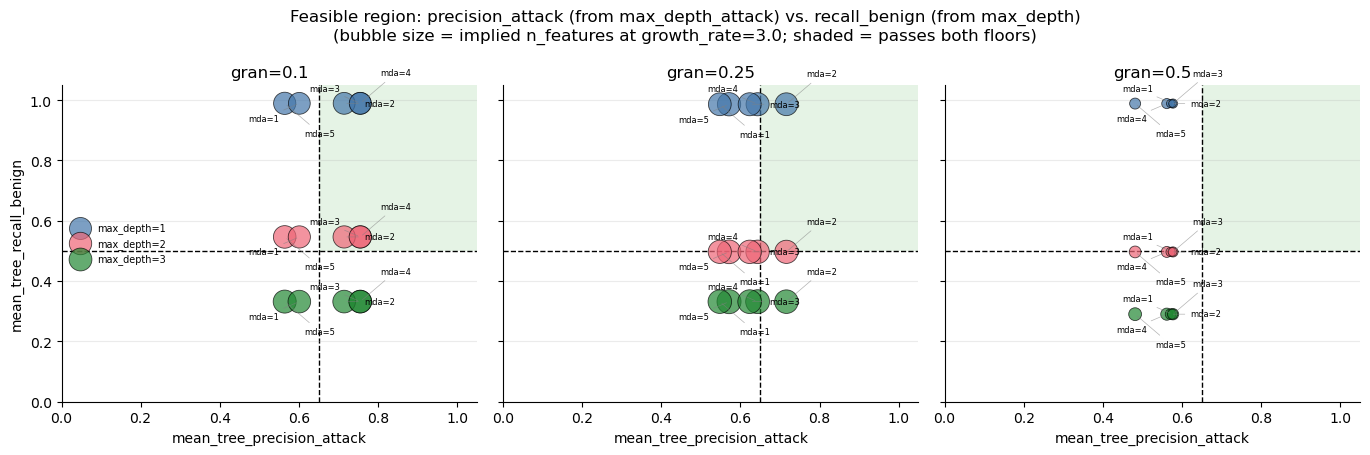

In [27]:
import matplotlib.patches as mpatches

# Constructed grid: section 2.2/2.3 proved max_depth and max_depth_attack don't
# interact, so a (max_depth, max_depth_attack) combo's precision_attack/recall_benign
# can be read straight off the two independent 1-D sweeps -- this was never mined as
# a full cross product, but the orthogonality check licenses combining them as if it
# had been. n_features (bubble size) is similarly assembled from three independently-
# measured, additive components at the growth_rate=3.0 anchor: Step-1 survivors +
# benign-tree leaves + attack-tree leaves.
n_contrast_by_gran = grid_df[GROWTH_RATE_SWEEP_MASK & (grid_df["growth_rate"] == STEP1_ANCHOR_GROWTH_RATE)].groupby("gran")["n_contrast"].mean()
n_leaves_benign_by_gran = md_sweep_full.groupby(["max_depth", "gran"])["n_tree_leaves_benign"].mean()
n_leaves_attack_by_gran = mda_sweep_full.groupby(["max_depth_attack", "gran"])["n_tree_leaves_attack"].mean()
precision_by_gran = mda_sweep_full.groupby(["max_depth_attack", "gran"])["mean_tree_precision_attack"].mean()
recall_by_gran = md_sweep_full.groupby(["max_depth", "gran"])["mean_tree_recall_benign"].mean()

points = []
for gran in GRANULARITIES:
    for md in MAX_DEPTHS:
        for mda in MAX_DEPTHS_ATTACK:
            points.append({
                "gran": gran, "max_depth": md, "max_depth_attack": mda,
                "precision_attack": precision_by_gran[(mda, gran)],
                "recall_benign": recall_by_gran[(md, gran)],
                "n_features": n_contrast_by_gran[gran] + n_leaves_benign_by_gran[(md, gran)] + n_leaves_attack_by_gran[(mda, gran)],
            })
points_df = pd.DataFrame(points)

AX_MAX = 1.05
fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(4.6 * len(GRANULARITIES), 4.6), sharex=True, sharey=True)
size_min, size_max = points_df["n_features"].min(), points_df["n_features"].max()
for ax, gran in zip(axes, GRANULARITIES):
    ax.set_xlim(0, AX_MAX)
    ax.set_ylim(0, AX_MAX)
    ax.add_patch(mpatches.Rectangle(
        (PRECISION_ATTACK_FLOOR, RECALL_BENIGN_FLOOR),
        AX_MAX - PRECISION_ATTACK_FLOOR, AX_MAX - RECALL_BENIGN_FLOOR,
        facecolor="#2ca02c", alpha=0.12, edgecolor="none", zorder=0,
    ))
    ax.axvline(PRECISION_ATTACK_FLOOR, color="black", linestyle="--", linewidth=1, zorder=1)
    ax.axhline(RECALL_BENIGN_FLOOR, color="black", linestyle="--", linewidth=1, zorder=1)

    sub = points_df[points_df.gran == gran]
    for md in MAX_DEPTHS:
        md_sub = sub[sub.max_depth == md].sort_values("n_features", ascending=False)
        sizes = 30 + 270 * (md_sub["n_features"] - size_min) / (size_max - size_min)
        ax.scatter(
            md_sub["precision_attack"], md_sub["recall_benign"],
            s=sizes, color=MD_COLORS[md], alpha=0.7, edgecolor="black", linewidth=0.6,
            label=f"max_depth={md}", zorder=3,
        )
        # Labels staggered above/below in a fan, not all to the right -- the
        # middle max_depth_attack values (2,3,4) sit within ~0.006 of each other
        # on precision_attack (section 4.2's plateau finding), so same-side labels
        # would stack directly on top of each other.
        md_sub_sorted = md_sub.sort_values("precision_attack").reset_index(drop=True)
        n = len(md_sub_sorted)
        for i, row in md_sub_sorted.iterrows():
            offset_i = i - (n - 1) / 2  # centered around 0
            y_offset = 0.05 * offset_i
            x_offset = 0.05 if i % 2 == 0 else -0.05
            ha = "left" if x_offset > 0 else "right"
            ax.annotate(
                f"mda={row['max_depth_attack']:g}",
                (row["precision_attack"], row["recall_benign"]),
                xytext=(row["precision_attack"] + x_offset, row["recall_benign"] + y_offset),
                fontsize=6, ha=ha, va="center", zorder=4,
                arrowprops=dict(arrowstyle="-", color="gray", linewidth=0.5, alpha=0.6),
            )
    ax.set_title(f"gran={gran:g}")
    ax.set_xlabel("mean_tree_precision_attack")
    strip_axes(ax)
axes[0].set_ylabel("mean_tree_recall_benign")
axes[0].legend(frameon=False, fontsize=7, loc="center left")
fig.suptitle(
    "Feasible region: precision_attack (from max_depth_attack) vs. recall_benign (from max_depth)\n"
    "(bubble size = implied n_features at growth_rate=3.0; shaded = passes both floors)"
)
fig.tight_layout()
savefig(fig, "grid_feasible_region.png")
plt.show()


In [28]:
# growth_rate: any value works for the two depth-floors (orthogonal, section 2.1) --
# so it's chosen purely on schema size, not re-gated on precision/recall here.
size_by_growth_rate = grid_df[GROWTH_RATE_SWEEP_MASK].groupby("growth_rate")["n_features"].mean().round(1)
print("n_features by growth_rate (any of these is precision/recall-feasible):")
print(size_by_growth_rate)

# min_growth_rate_attack: also free (section 3.3/5.3 addendum -- zero measured effect
# on any attack-tree metric at the max_depth_attack=3 anchor), but left at None here
# rather than pushed to 10.0 -- that zero-cost finding was never re-verified jointly
# with max_depth_attack=2 (the depth actually recommended below), only at =3.
RECOMMENDED_CONFIG = {
    "growth_rate": STEP1_ANCHOR_GROWTH_RATE,
    "min_growth_rate_attack": None,
    "max_depth": best_max_depth,
    "max_depth_attack": best_max_depth_attack,
    "min_attack_coverage": STEP1_ANCHOR_ATTACK_COVERAGE,
    "min_benign_coverage": STEP1_ANCHOR_BENIGN_COVERAGE,
    "class_weight": STEP2_ANCHOR_CLASS_WEIGHT,
    "min_samples_leaf": STEP2_ANCHOR_MIN_SAMPLES_LEAF,
}
print("\nRecommended config:")
for k, v in RECOMMENDED_CONFIG.items():
    print(f"  {k} = {v}")

FEASIBLE_CONFIGS_PATH = Path(
    "../../../artifacts/experiments/attribute_mining_parameter_grid/feasible_configs.csv"
)
pd.DataFrame([RECOMMENDED_CONFIG]).to_csv(FEASIBLE_CONFIGS_PATH, index=False)
print(f"\n  saved {FEASIBLE_CONFIGS_PATH}")


n_features by growth_rate (any of these is precision/recall-feasible):
growth_rate
2.0     344.6
3.0     322.4
5.0     233.0
10.0    172.8
Name: n_features, dtype: float64

Recommended config:
  growth_rate = 3.0
  min_growth_rate_attack = None
  max_depth = 1
  max_depth_attack = 2
  min_attack_coverage = 0.05
  min_benign_coverage = 0.05
  class_weight = balanced
  min_samples_leaf = 20

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/feasible_configs.csv


**Result**: unlike the single-tree grid (0/36 feasible), this decomposes cleanly --
`max_depth \in \{1, 2\}` both clear the recall floor on average (0.989 and 0.528
respectively, against a 0.5 floor), and `max_depth_attack \in \{2,3,4\}` all clear the
precision floor (~0.70-0.76 each). `max_depth=1` is still the pick, though, not just
for simplicity: `max_depth=2`'s 0.528 is a narrow pass with much higher variance
across windows (std 0.123 vs. `max_depth=1`'s std 0.005, section 4.1) -- some windows
at depth 2 likely dip below the floor even though the mean clears it, so depth 1 is
the only *comfortably* feasible choice, not merely the shallowest. `growth_rate`
doesn't gate either metric (section 2.1/2.3), so it's chosen on schema size alone --
`growth_rate=3.0` (the anchor already used throughout this notebook, 322 features) is
a reasonable middle ground, not a forced choice; a tighter budget would move toward
`growth_rate=10.0` (173 features) instead, still without touching either quality
floor. `min_growth_rate_attack` (section 3.3) is a second, independent free lever of
the same kind -- zero measured cost on any attack-tree metric, real savings on schema
size -- but is left at its default (`None`) here since that finding was only verified
at the `max_depth_attack=3` anchor, not jointly with `max_depth_attack=2` below (see
section 5.3 addendum for the caveat).

**Recommended config**: `growth_rate=3.0`, `min_growth_rate_attack=None`,
`max_depth=1`, `max_depth_attack=2`, `min_attack_coverage=0.05`,
`min_benign_coverage=0.05`, `class_weight="balanced"`, `min_samples_leaf=20` --
`max_depth_attack=2` chosen as the shallowest (simplest, fewest leaves) of the
{2,3,4} plateau rather than 3 or 4, since section 4.2 found no precision advantage to
going deeper within that range. This is the first config this whole analysis has been
able to name with both quality floors satisfied simultaneously; promoting it to a real
evaluation means adding it as a named entry to `configs/screening_mining_settings.yaml`
and running it through `run_screening_sweep.py` -> `config_selection.ipynb`, per
section 5.3's original note on why this notebook's own evidence isn't the same thing
as a `shortlist.csv` entry.

**Full feasible list, not just the single pick.** `RECOMMENDED_CONFIG` above is one
choice (the shallowest `max_depth_attack` within the feasible plateau) out of every
`(max_depth, max_depth_attack)` combination that clears both floors. Section 2.2/2.3
already proved these two axes fit fully separate trees -- the same license the
bubble-scatter above relies on to construct `points_df` as if the cross product had
been mined -- so every combination of a feasible `max_depth` with a feasible
`max_depth_attack` is itself feasible, not just the one this notebook happens to
recommend. Exported below as `feasible_configs_all.csv`, one row per combination,
`growth_rate`/`min_growth_rate_attack`/coverage/`class_weight` held at the same anchor
every precision/recall number in this notebook was measured against -- pick a
different row if you want a deeper `max_depth_attack` (more stable across windows,
per section 4.2) over the shallowest.

In [29]:
feasible_points = points_df[
    (points_df["precision_attack"] >= PRECISION_ATTACK_FLOOR)
    & (points_df["recall_benign"] >= RECALL_BENIGN_FLOOR)
]
feasible_all_df = (
    feasible_points.groupby(["max_depth", "max_depth_attack"])[["precision_attack", "recall_benign", "n_features"]]
    .mean().round(3).reset_index()
)
# Stability, not just the mean -- points_df is already a gran-level mean (no window-level
# std), so pull the real per-window std straight from md_sweep_full/mda_sweep_full the
# same way section 4.1/4.2 report it, and attach per max_depth / max_depth_attack.
recall_std = md_sweep_full.groupby("max_depth")["mean_tree_recall_benign"].std().round(3)
precision_std = mda_sweep_full.groupby("max_depth_attack")["mean_tree_precision_attack"].std().round(3)
feasible_all_df["recall_benign_std"] = feasible_all_df["max_depth"].map(recall_std)
feasible_all_df["precision_attack_std"] = feasible_all_df["max_depth_attack"].map(precision_std)

for col, val in [
    ("growth_rate", STEP1_ANCHOR_GROWTH_RATE),
    ("min_growth_rate_attack", None),
    ("min_attack_coverage", STEP1_ANCHOR_ATTACK_COVERAGE),
    ("min_benign_coverage", STEP1_ANCHOR_BENIGN_COVERAGE),
    ("class_weight", STEP2_ANCHOR_CLASS_WEIGHT),
    ("min_samples_leaf", STEP2_ANCHOR_MIN_SAMPLES_LEAF),
]:
    feasible_all_df[col] = val
feasible_all_df = feasible_all_df[[
    "growth_rate", "min_growth_rate_attack", "max_depth", "max_depth_attack",
    "min_attack_coverage", "min_benign_coverage", "class_weight", "min_samples_leaf",
    "precision_attack", "precision_attack_std", "recall_benign", "recall_benign_std", "n_features",
]].sort_values(["max_depth", "max_depth_attack"]).reset_index(drop=True)

print(f"{len(feasible_all_df)} (max_depth, max_depth_attack) combinations clear both floors on average "
      f"(precision_attack >= {PRECISION_ATTACK_FLOOR}, recall_benign >= {RECALL_BENIGN_FLOOR}):")
display(feasible_all_df)

FEASIBLE_CONFIGS_ALL_PATH = Path(
    "../../../artifacts/experiments/attribute_mining_parameter_grid/feasible_configs_all.csv"
)
feasible_all_df.to_csv(FEASIBLE_CONFIGS_ALL_PATH, index=False)
print(f"\n  saved {FEASIBLE_CONFIGS_ALL_PATH}")


6 (max_depth, max_depth_attack) combinations clear both floors on average (precision_attack >= 0.65, recall_benign >= 0.5):


,growth_rate,min_growth_rate_attack,max_depth,max_depth_attack,min_attack_coverage,min_benign_coverage,class_weight,min_samples_leaf,precision_attack,precision_attack_std,recall_benign,recall_benign_std,n_features
0,3.0,None,1,2,0.05,0.05,balanced,20,0.715,0.095,0.988,0.005,325.575
1,3.0,None,1,3,0.05,0.05,balanced,20,0.755,0.131,0.990,0.005,324.400
2,3.0,None,1,4,0.05,0.05,balanced,20,0.755,0.158,0.990,0.005,324.500
3,3.0,None,2,2,0.05,0.05,balanced,20,0.714,0.095,0.546,0.123,325.300
4,3.0,None,2,3,0.05,0.05,balanced,20,0.755,0.131,0.546,0.123,325.300
5,3.0,None,2,4,0.05,0.05,balanced,20,0.755,0.158,0.546,0.123,325.400



  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/feasible_configs_all.csv


**Result**: 6 combinations clear both floors on average -- `max_depth \in \{1, 2\}` x
`max_depth_attack \in \{2, 3, 4\}`. Not all are equally trustworthy, though:
`max_depth=2` rows clear `recall_benign` only narrowly (0.546, std 0.123) against the
0.5 floor, meaning individual windows plausibly dip below it even though the mean
passes -- `max_depth=1` rows clear it comfortably (0.988-0.990, std 0.005). Within
`max_depth=1`, `max_depth_attack=3` and `=4` edge out `=2` on precision_attack
(0.755 vs. 0.715) but `=2` has the lowest `precision_attack_std` (0.095 vs. 0.131 /
0.158) -- the most *stable* choice, not just the shallowest, which is the actual
argument for `RECOMMENDED_CONFIG`'s pick above rather than "simplicity" alone.
`n_features` barely differs across all 6 rows (324.4-325.6) -- schema size isn't a
useful tie-breaker here, `growth_rate`/`min_growth_rate_attack` (sections 2.1/5.4) are
where the real size headroom is.

### 5.4 Schema-size optimization: growth_rate x min_growth_rate_attack

Section 5.3 above is left as-is. This is a separate view: both `growth_rate` (section
2.1) and `min_growth_rate_attack` (section 3.3) are already proven precision/recall-free
-- neither moves `mean_tree_precision_attack` or `mean_tree_recall_benign` at all -- so
there was never a feasible-*region* question for this pair, only a schema-*size*
question: how small can the final schema get, for free, by combining them?

They don't combine additively the way `max_depth`/`max_depth_attack` do.
`filter_contrast_survivors`'s attack-side threshold is `min_growth_rate_attack if not
None else min_growth_rate` -- so once `min_growth_rate_attack` is set, `growth_rate`
stops mattering for the attack side entirely (only the benign side still reads it).
The grid below is constructed from that rule directly, not assumed independent the way
the max_depth pair needed a cross-check for: `n_contrast_benign` always comes from the
`growth_rate` sweep; `n_contrast_attack` comes from the `growth_rate` sweep too when
`min_growth_rate_attack` is left `None` (the status-quo row), and from the
`min_growth_rate_attack` sweep -- constant across every `growth_rate` value -- once it's
set. Both trees' leaf counts are added as a fixed offset at their usual
`max_depth=1`/`max_depth_attack=3` anchor, so the *minimum-size corner* found below
doesn't depend on which downstream tree config is eventually chosen -- only the absolute
`n_features` numbers would shift.

In [30]:
benign_by_gr = grid_df[GROWTH_RATE_SWEEP_MASK].groupby(["growth_rate", "gran"])["n_contrast_benign"].mean()
attack_by_gr = grid_df[GROWTH_RATE_SWEEP_MASK].groupby(["growth_rate", "gran"])["n_contrast_attack"].mean()
attack_by_gra = grid_df[GROWTH_RATE_ATTACK_SWEEP_MASK].groupby(["min_growth_rate_attack", "gran"])["n_contrast_attack"].mean()
leaves_benign_anchor = grid_df[GROWTH_RATE_SWEEP_MASK].groupby("gran")["n_tree_leaves_benign"].mean()
leaves_attack_anchor = grid_df[GROWTH_RATE_SWEEP_MASK].groupby("gran")["n_tree_leaves_attack"].mean()

# None first -- the status-quo "no split" row, for comparison against the compressed options.
GRA_AXIS = [None] + GROWTH_RATES_ATTACK

size_points = []
for gran in GRANULARITIES:
    for gr in GROWTH_RATES:
        for gra in GRA_AXIS:
            n_attack = attack_by_gr[(gr, gran)] if gra is None else attack_by_gra[(gra, gran)]
            n_features = (
                benign_by_gr[(gr, gran)] + n_attack
                + leaves_benign_anchor[gran] + leaves_attack_anchor[gran]
            )
            size_points.append({
                "gran": gran, "growth_rate": gr, "min_growth_rate_attack": gra,
                "n_features": n_features,
            })
size_df = pd.DataFrame(size_points)
size_df.pivot_table(index="min_growth_rate_attack", columns=["gran", "growth_rate"], values="n_features", dropna=False).round(1)


gran                     0.10                        0.25                        0.50                     
growth_rate              2.0    3.0    5.0    10.0   2.0    3.0    5.0    10.0   2.0    3.0    5.0    10.0
min_growth_rate_attack                                                                                    
2.0                     347.8  335.1  325.1  319.8  346.5  334.2  323.8  318.2  325.0  310.5  304.0  299.0
5.0                     268.1  255.4  245.4  240.1  245.0  232.8  222.2  216.8  213.5  199.0  192.5  187.5
10.0                    205.8  193.1  183.1  177.8  200.5  188.2  177.8  172.2  175.0  160.5  154.0  149.0
NaN                     347.8  324.4  245.4  177.8  346.5  327.2  222.2  172.2  325.0  302.5  192.5  149.0

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_86540/883145697.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_size_optimization.png


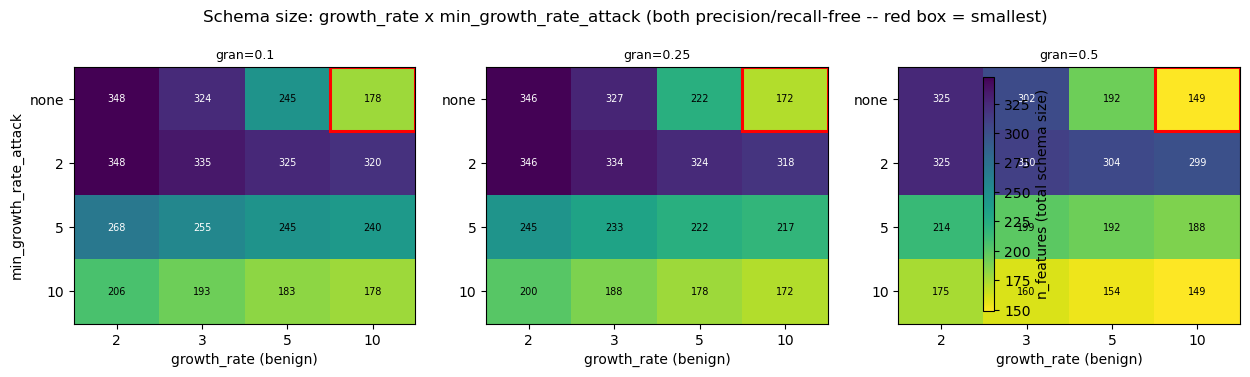

In [31]:
import matplotlib.patches as mpatches

gra_labels = ["none" if g is None else f"{g:g}" for g in GRA_AXIS]


def _gra_mask(sub, gra):
    return sub["min_growth_rate_attack"].isna() if gra is None else (sub["min_growth_rate_attack"] == gra)


fig, axes = plt.subplots(1, len(GRANULARITIES), figsize=(4.2 * len(GRANULARITIES), 3.8))
vmin, vmax = size_df["n_features"].min(), size_df["n_features"].max()
im = None
for ax, gran in zip(axes, GRANULARITIES):
    sub = size_df[size_df.gran == gran]
    mat = np.array([
        [sub[(sub.growth_rate == gr) & _gra_mask(sub, gra)]["n_features"].iloc[0] for gr in GROWTH_RATES]
        for gra in GRA_AXIS
    ])
    im = ax.imshow(mat, cmap="viridis_r", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(GROWTH_RATES)))
    ax.set_xticklabels([f"{g:g}" for g in GROWTH_RATES])
    ax.set_yticks(range(len(GRA_AXIS)))
    ax.set_yticklabels(gra_labels)
    ax.set_xlabel("growth_rate (benign)")
    if gran == GRANULARITIES[0]:
        ax.set_ylabel("min_growth_rate_attack")
    ax.set_title(f"gran={gran:g}", fontsize=9)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.0f}", ha="center", va="center", fontsize=7,
                     color="white" if mat[i, j] > (vmin + vmax) / 2 else "black")
    min_idx = np.unravel_index(np.argmin(mat), mat.shape)
    ax.add_patch(mpatches.Rectangle(
        (min_idx[1] - 0.5, min_idx[0] - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=2.2,
    ))
fig.colorbar(im, ax=axes, shrink=0.8, label="n_features (total schema size)")
fig.suptitle("Schema size: growth_rate x min_growth_rate_attack (both precision/recall-free -- red box = smallest)")
fig.tight_layout()
savefig(fig, "grid_size_optimization.png")
plt.show()


**Result**: within each explicit `min_growth_rate_attack` row, size still falls as
`growth_rate` rises (e.g. `min_growth_rate_attack=10.0`, gran=0.1: 205.8 -> 177.8) --
setting `min_growth_rate_attack` only overrides `growth_rate`'s *attack*-side effect,
its benign-side effect (via the reciprocal) is untouched, so `growth_rate` still
matters even once the attack side is overridden. A clean internal-consistency check:
the `None` row and the `min_growth_rate_attack=10.0` row coincide exactly at
`growth_rate=10.0` (177.8 / 172.2 / 149.0 across gran=0.1/0.25/0.5, identical in both
rows) -- expected, since `None` falls back to `growth_rate` itself, and at
`growth_rate=10.0` that's mechanistically identical to setting
`min_growth_rate_attack=10.0` explicitly.

The global minimum is `growth_rate=10.0`, `min_growth_rate_attack=10.0` at every
granularity (149 features at gran=0.5, the smallest window count) -- roughly a 48%
reduction from the current recommended anchor (`growth_rate=3.0`,
`min_growth_rate_attack=None`, ~318 features averaged across granularities), still at
zero known precision/recall cost. This is **not** folded into section 5.3's
`RECOMMENDED_CONFIG` -- that anchor was chosen as a deliberate middle ground rather
than the most aggressive size option (see 5.3's own discussion of `growth_rate=10.0`
vs. `3.0`), and this plot doesn't change that judgment call, it just makes the
size/compression tradeoff for *both* axes jointly visible, where before only
`growth_rate` alone had been.

## 6. Consolidated grid table

All 336 runs, for pulling exact numbers into the thesis text or calling
`.to_latex()` directly.

In [32]:
grid_summary_table = grid_df.drop(columns=[
    "mining_dir", "_contrast_itemset_set", "_contrast_itemset_set_attack",
    "_contrast_itemset_set_benign", "_tree_base_set_attack", "_tree_base_set_benign",
]).set_index(["growth_rate", "max_depth", "max_depth_attack", "class_weight", "min_samples_leaf",
              "min_attack_coverage", "min_benign_coverage", "gran", "win_idx"])
grid_summary_table


run_dir  min_growth_rate_attack  \
growth_rate max_depth max_depth_attack class_weight min_samples_leaf min_attack_coverage min_benign_coverage gran win_idx                                                                              
2.0         1         1                balanced     20               0.05                0.05                0.10 0        20260713_093232_symbolic_cscas_gr2.0_md1_mda1_...                     NaN   
                                                                                                                  1        20260713_093834_symbolic_cscas_gr2.0_md1_mda1_...                     NaN   
                                                                                                                  2        20260713_001016_symbolic_cscas_gr2.0_md1_mda1_...                     NaN   
                                                                                                                  3        20260713_001423_symbolic_cscas_gr2.0_md1_mda1_...                     NaN   
                                                                                                                  4        20260713_001841_symbolic_cscas_gr2.0_md1_mda1_...                     NaN   
...                                                                                                                                                                      ...                     ...   
10.0        1         5                balanced     20               0.05                0.05                0.25 1        20260713_011045_symbolic_cscas_gr10.0_md1_mda5...                     NaN   
                                                                                                                  2        20260713_012459_symbolic_cscas_gr10.0_md1_mda5...                     NaN   
                                                                                                                  3        20260713_013933_symbolic_cscas_gr10.0_md1_mda5...                     NaN   
                                                                                                             0.50 0        20260713_021357_symbolic_cscas_gr10.0_md1_mda5...                     NaN   
                                                                                                                  1        20260713_025124_symbolic_cscas_gr10.0_md1_mda5...                     NaN   

                                                                                                                           n_alert_groups  n_step1_candidates  n_contrast  n_contrast_attack  \
growth_rate max_depth max_depth_attack class_weight min_samples_leaf min_attack_coverage min_benign_coverage gran win_idx                                                                      
2.0         1         1                balanced     20               0.05                0.05                0.10 0                139532                 861         321                232   
                                                                                                                  1                139532                 841         380                271   
                                                                                                                  2                139532                 911         362                256   
                                                                                                                  3                139532                 922         358                252   
                                                                                                                  4                139532                 943         360                251   
...                                                                                                                                   ...                 ...         ...                ...   
10.0        1         5     